# Mass Balance — GRACE-aligned (3 mascon blocks)

Okavango Delta water budget with **P**, **ET**, **Q** and **GRACE ΔS** all
computed over the same three JPL mascon blocks (NE + SE + SW) that overlap the
delta polygon.  Dropping the NW block (1.6 % of the delta) eliminates a large
dry-Kalahari footprint while retaining 98.4 % of the delta polygon coverage.

$$Q_{\text{in}} + P - ET \approx \Delta S + Q_{\text{out}} + G$$

## 1 — Setup

In [1]:
from pathlib import Path
import hashlib
from collections import defaultdict

import numpy as np
import pandas as pd
import geopandas as gpd
import xarray as xr
import folium
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import ee
from IPython.display import display
from shapely.geometry import box as shapely_box, Polygon, MultiPolygon
from shapely.ops import unary_union
from shapely.prepared import prep

from src.gee_utils import ee_init

# ── Paths ──
DELTA_SHP = Path("../data/regions/Delta_UCB_WGS84/Delta_UCB_WGS84.shp")
GRACE_NC  = Path("../data/grace_subsaharan_out/"
                  "GRCTellus.JPL.200204_202507.GLO.RL06.3M.MSCNv04CRI.nc")
MOHEMBO_MONTHLY = Path("../data/mohembo_1357100_Q_monthly_mean.csv")

assert DELTA_SHP.exists(), f"Missing: {DELTA_SHP.resolve()}"
assert GRACE_NC.exists(),  f"Missing: {GRACE_NC.resolve()}"

# ── Time window ──
START = "2002-04-01"   # GRACE begins April 2002
END = (pd.Timestamp.today().normalize()
       + pd.offsets.MonthBegin(1)).strftime("%Y-%m-%d")

# ── Output ──
GEOM_TAG = "grace_3block"
FIG_DIR  = Path("../figures/ET comparison") / GEOM_TAG
FIG_DIR.mkdir(parents=True, exist_ok=True)

# ── Toggle: set False after EE calls have run once and CSVs are cached ──
RUN_EE = True

print(f"Window : {START} → {END}")
print(f"Figures: {FIG_DIR.resolve()}")

Window : 2002-04-01 → 2026-05-01
Figures: /Users/octaviacrompton/Projects/dswe-inman-lyons/figures/ET comparison/grace_3block


In [2]:
gdf = gpd.read_file(DELTA_SHP).to_crs(epsg=4326)
delta_union = gdf.unary_union
centroid = delta_union.centroid
print(f"Delta bounds: {delta_union.bounds}")

Delta bounds: (21.79128644270243, -20.185785441436625, 24.033221169007163, -18.26936168824883)


## 2 — Discover GRACE mascon blocks

In [3]:
ds_grace = xr.open_dataset(GRACE_NC)
da = ds_grace["lwe_thickness"]

lats_all = da["lat"].values
lons_all = da["lon"].values
dlat = float(np.median(np.abs(np.diff(lats_all))))
dlon = float(np.median(np.abs(np.diff(lons_all))))

# Generous window around the delta
pad_deg = 4.0
raw_minx, raw_miny, raw_maxx, raw_maxy = delta_union.bounds
da_sub = da.sel(
    lon=lons_all[(lons_all >= raw_minx - pad_deg) & (lons_all <= raw_maxx + pad_deg)],
    lat=lats_all[(lats_all >= raw_miny - pad_deg) & (lats_all <= raw_maxy + pad_deg)],
)

ts = (da_sub.stack(cell=("lat", "lon"))
      .transpose("time", "cell")
      .dropna("cell", how="all"))
cell_index = ts["cell"].to_index()
arr = ts.values

# Hash each 0.5° pixel's full time series → group into mascon blocks
groups = defaultdict(list)
for i in range(arr.shape[1]):
    v = np.round(arr[:, i].astype("float64"), 6)
    v = np.where(np.isnan(v), -9999.0, v)
    groups[hashlib.md5(v.tobytes()).hexdigest()].append(i)

delta_poly = (Polygon(delta_union.exterior.coords)
              if delta_union.geom_type == "Polygon" else delta_union)
P_prep = prep(delta_poly)

blocks = []
for k, idxs in enumerate(groups.values(), start=1):
    lc = np.array([cell_index[j][0] for j in idxs], dtype=float)
    lo = np.array([cell_index[j][1] for j in idxs], dtype=float)
    lat0, lat1 = float(lc.min() - dlat/2), float(lc.max() + dlat/2)
    lon0, lon1 = float(lo.min() - dlon/2), float(lo.max() + dlon/2)
    bpoly = shapely_box(lon0, lat0, lon1, lat1)

    blat_c = (lat0 + lat1) / 2
    blon_c = (lon0 + lon1) / 2
    ns = "N" if blat_c > centroid.y else "S"
    ew = "W" if blon_c < centroid.x else "E"

    blocks.append(dict(
        block_id=f"B{k:03d}", quadrant=f"{ns}{ew}",
        lat0=lat0, lat1=lat1, lon0=lon0, lon1=lon1,
        n_pixels=len(idxs),
        intersects_delta=P_prep.intersects(bpoly),
    ))

ds_grace.close()

delta_blocks = [b for b in blocks if b["intersects_delta"]]
for b in sorted(delta_blocks, key=lambda x: (-x["lat1"], x["lon0"])):
    bpoly = shapely_box(b["lon0"], b["lat0"], b["lon1"], b["lat1"])
    frac = delta_poly.intersection(bpoly).area / delta_poly.area
    print(f"  {b['block_id']}  ({b['quadrant']})  "
          f"lon {b['lon0']:6.2f}–{b['lon1']:6.2f}  "
          f"lat {b['lat0']:7.2f}–{b['lat1']:6.2f}  "
          f"frac_delta={frac:.1%}")

  B010  (NW)  lon  19.00– 22.00  lat  -19.50–-16.50  frac_delta=1.6%
  B011  (NE)  lon  22.00– 25.50  lat  -19.50–-16.50  frac_delta=60.7%
  B006  (SW)  lon  19.50– 22.50  lat  -22.50–-19.50  frac_delta=4.7%
  B007  (SE)  lon  22.50– 25.50  lat  -22.50–-19.50  frac_delta=33.0%


In [4]:
# Drop the NW block (< 2 % of delta)
USE_BLOCKS = [b for b in delta_blocks if b["quadrant"] != "NW"]
print("Selected blocks:", [b["block_id"] + " " + b["quadrant"] for b in USE_BLOCKS])

block_polys = [shapely_box(b["lon0"], b["lat0"], b["lon1"], b["lat1"])
               for b in USE_BLOCKS]
block_union = unary_union(block_polys)

block_union_area_deg2 = block_union.area
frac_covered = sum(
    delta_poly.intersection(p).area for p in block_polys
) / delta_poly.area
print(f"3-block union area   : ~{block_union_area_deg2:.1f} deg²")
print(f"Delta polygon covered: {frac_covered:.1%}")

Selected blocks: ['B006 SW', 'B007 SE', 'B011 NE']
3-block union area   : ~28.5 deg²
Delta polygon covered: 98.4%


In [5]:
m = folium.Map(location=[centroid.y, centroid.x], zoom_start=7, tiles=None)

folium.TileLayer("CartoDB positron", name="Carto Positron").add_to(m)
folium.TileLayer(
    tiles="https://server.arcgisonline.com/ArcGIS/rest/services/"
          "World_Imagery/MapServer/tile/{z}/{y}/{x}",
    attr="Esri", name="Esri Imagery", overlay=False, control=True,
).add_to(m)

# Delta polygon
folium.GeoJson(
    gdf.__geo_interface__, name="Delta polygon",
    style_function=lambda f: {"color": "#8c2d04", "weight": 3, "fillOpacity": 0.15},
).add_to(m)

# All discovered blocks (grey for non-selected)
grid_fg = folium.FeatureGroup(name="Mascon blocks (all)", show=True)
for b in blocks:
    selected = any(b["block_id"] == u["block_id"] for u in USE_BLOCKS)
    folium.Rectangle(
        bounds=[[b["lat0"], b["lon0"]], [b["lat1"], b["lon1"]]],
        color="#1b9e77" if selected else "#bbbbbb",
        weight=2 if selected else 1,
        fill=selected, fill_opacity=0.12 if selected else 0.0,
        tooltip=f"{b['block_id']} ({b['quadrant']})  {b['n_pixels']} px",
    ).add_to(grid_fg)
grid_fg.add_to(m)

# 3-block union outline
ub = block_union.bounds
folium.Rectangle(
    bounds=[[ub[1], ub[0]], [ub[3], ub[2]]],
    color="#2ca02c", weight=3, fill=False, dash_array="6",
    tooltip="3-block union",
).add_to(m)

folium.LayerControl(collapsed=False).add_to(m)
m

## 3 — Earth Engine geometry + area

In [6]:
ee_init()

# Build an EE MultiPolygon from the Shapely block geometries
coords_list = []
for bp in block_polys:
    coords_list.append([list(c) for c in bp.exterior.coords])

block_geom = ee.Geometry.MultiPolygon(coords_list, proj="EPSG:4326", geodesic=True)
block_area_m2 = float(block_geom.area(maxError=1).getInfo())
print(f"3-block union area (EE): {block_area_m2 / 1e6:.0f} km²")

3-block union area (EE): 331266 km²


## 4 — Monthly ET over 3-block union

In [7]:
# ── Reusable helper functions (same as ET comparison notebook) ──

def monthly_sequence(start_date, end_date):
    s, e = ee.Date(start_date), ee.Date(end_date)
    return ee.List.sequence(0, e.difference(s, "month").toInt().subtract(1))

def make_monthly_et_ic(ic, to_mm_fn, start_date, end_date):
    start = ee.Date(start_date)
    def month_img(m):
        m = ee.Number(m)
        m0 = start.advance(m, "month")
        m1 = m0.advance(1, "month")
        sub = ic.filterDate(m0, m1).map(to_mm_fn)
        mm = ee.Image(ee.Algorithms.If(sub.size().gt(0), sub.sum(),
                                        ee.Image.constant(0)))
        return (mm.rename("et_mm")
                .set({"system:time_start": m0.millis(),
                      "system:index": m0.format("YYYYMM"),
                      "ym": m0.format("YYYY-MM")}))
    months = ee.List(ee.Algorithms.If(
        ee.Date(end_date).difference(start, "month").toInt().gt(0),
        monthly_sequence(start_date, end_date), ee.List([])))
    return ee.ImageCollection.fromImages(months.map(month_img))

def monthly_totals_m3_chunked(monthly_ic, region, scale_m,
                               chunk_months=24, tile_scale=8):
    n = int(monthly_ic.size().getInfo())
    if n == 0:
        return {}
    imgs = monthly_ic.toList(n)
    out = {}
    for i in range(0, n, chunk_months):
        sub = ee.ImageCollection.fromImages(imgs.slice(i, min(i + chunk_months, n)))
        def to_m3(img):
            img = ee.Image(img)
            idx = ee.String(img.get("system:index"))
            return (img.select("et_mm").unmask(0)
                    .divide(1000).multiply(ee.Image.pixelArea())
                    .rename("et_m3").set("system:index", idx))
        bands_img = sub.map(to_m3).toBands()
        d = bands_img.reduceRegion(
            reducer=ee.Reducer.sum(), geometry=region,
            scale=scale_m, maxPixels=1e13, tileScale=tile_scale).getInfo()
        out.update(d)
    return out

def et_totals_to_df(totals, dataset_name, area_m2):
    rows = []
    for k, v in totals.items():
        yyyymm = k.split("_")[0]
        date = pd.to_datetime(yyyymm + "01", format="%Y%m%d")
        m3 = float(v) if v is not None else 0.0
        rows.append({"dataset": dataset_name, "date": date,
                      "et_km3_total": m3 / 1e9,
                      "et_mm_mean": (m3 / area_m2) * 1000.0})
    return pd.DataFrame(rows).sort_values("date").reset_index(drop=True)

print("ET helpers defined.")

ET helpers defined.


In [8]:
# ── Converter functions (native timestep → mm) ──
def mod16_mm(img):
    return img.select("ET").multiply(0.1)

def terraclimate_mm(img):
    return img.select("aet").multiply(0.1)

def fldas_mm(img):
    d0 = ee.Date(img.get("system:time_start"))
    secs = d0.advance(1, "month").difference(d0, "second")
    return img.select("Evap_tavg").multiply(secs)

def era5_land_mm(img):
    return img.select("total_evaporation_sum").multiply(-1000)

def pml_mm(img):
    return img.select("ET").multiply(0.01).multiply(8)

def wapor_mm(img):
    d0 = ee.Date(img.get("system:time_start"))
    d1_cand = d0.advance(10, "day")
    m_end = ee.Date.fromYMD(d0.get("year"), d0.get("month"), 1).advance(1, "month")
    d1 = ee.Date(ee.Algorithms.If(d1_cand.millis().lte(m_end.millis()), d1_cand, m_end))
    return img.select("L1-AETI-D").multiply(0.1).multiply(d1.difference(d0, "day"))

DATASETS = [
    dict(name="MOD16A2GF_v61",    id="MODIS/061/MOD16A2GF",  to_mm=mod16_mm,  scale=500,   start="2000-01-01"),
    dict(name="PML_v2_landET",     id="projects/pml_evapotranspiration/PML/OUTPUT/PML_V22a",
         to_mm=pml_mm, scale=500, start="2000-01-01"),
    dict(name="TerraClimate_aet",  id="IDAHO_EPSCOR/TERRACLIMATE",  to_mm=terraclimate_mm,  scale=4638,  start="1958-01-01"),
    dict(name="FLDAS_Evap",        id="NASA/FLDAS/NOAH01/C/GL/M/V001",  to_mm=fldas_mm,  scale=11132, start="1982-01-01"),
    dict(name="ERA5Land_totalET",  id="ECMWF/ERA5_LAND/MONTHLY_AGGR",   to_mm=era5_land_mm, scale=11132, start="1950-02-01"),
    dict(name="USGS_SSEBop",
         id="projects/earthengine-legacy/assets/projects/usgs-ssebop/modis_et_v5_monthly",
         to_mm=lambda img: img.select("et"), scale=1000, start="2003-01-01"),
    dict(name="WaPORv3_AETI",      id="FAO/WAPOR/3/L1_AETI_D",  to_mm=wapor_mm,  scale=248,  start="2018-01-01"),
]

ET_CSV = FIG_DIR / "et_monthly.csv"

if RUN_EE:
    dfs_et = []
    for ds in DATASETS:
        ds_start = max(pd.to_datetime(START), pd.to_datetime(ds["start"])).strftime("%Y-%m-%d")
        if pd.to_datetime(ds_start) >= pd.to_datetime(END):
            continue
        ic = (ee.ImageCollection(ds["id"])
              .filterBounds(block_geom).filterDate(ds_start, END))
        mic = make_monthly_et_ic(ic, ds["to_mm"], ds_start, END)
        n = int(mic.size().getInfo())
        print(f"{ds['name']}: {n} months  ({ds_start} → {END})")
        totals = monthly_totals_m3_chunked(mic, block_geom, scale_m=ds["scale"])
        dfs_et.append(et_totals_to_df(totals, ds["name"], block_area_m2))

    df_et_all = pd.concat(dfs_et, ignore_index=True).sort_values(["dataset", "date"])
    df_et_all.to_csv(ET_CSV, index=False)
    print(f"Saved: {ET_CSV}  ({len(df_et_all)} rows)")
else:
    df_et_all = pd.read_csv(ET_CSV, parse_dates=["date"])
    print(f"Loaded cached: {ET_CSV}  ({len(df_et_all)} rows)")

MOD16A2GF_v61: 288 months  (2002-04-01 → 2026-05-01)
PML_v2_landET: 288 months  (2002-04-01 → 2026-05-01)
TerraClimate_aet: 288 months  (2002-04-01 → 2026-05-01)
FLDAS_Evap: 288 months  (2002-04-01 → 2026-05-01)
ERA5Land_totalET: 288 months  (2002-04-01 → 2026-05-01)
USGS_SSEBop: 279 months  (2003-01-01 → 2026-05-01)
WaPORv3_AETI: 99 months  (2018-01-01 → 2026-05-01)
Saved: ../figures/ET comparison/grace_3block/et_monthly.csv  (1818 rows)


In [9]:
# ── GLEAM v4.2a monthly ET (from local netCDFs) ──
GLEAM_DIR = Path("../data/gleam")
GLEAM_FILES = sorted(GLEAM_DIR.glob("E_*_GLEAM_v4.2a_MO.nc"))

if GLEAM_FILES:
    # Bounding box of the 3-block union for spatial clip
    blon0, blat0, blon1, blat1 = block_union.bounds

    dsets = []
    for f in GLEAM_FILES:
        ds = xr.open_dataset(f)
        # GLEAM v4.2a has lat descending (90 → -90), so slice high → low
        dsets.append(ds.sel(lon=slice(blon0 - 0.5, blon1 + 0.5),
                            lat=slice(blat1 + 0.5, blat0 - 0.5)))

    da_gleam = xr.concat(dsets, dim="time").sortby("time")
    for d in dsets:
        d.close()

    et_da = da_gleam["E"]  # actual ET in mm/month

    # Build pixel-area weights (cos-lat on regular 0.1° grid)
    lats = et_da["lat"].values
    lons = et_da["lon"].values
    dlat_g = abs(float(np.median(np.diff(lats))))
    dlon_g = abs(float(np.median(np.diff(lons))))

    R = 6.371e6  # Earth radius in metres
    pixel_area = (R**2 * np.deg2rad(dlon_g)
                  * np.abs(np.sin(np.deg2rad(lats + dlat_g / 2))
                           - np.sin(np.deg2rad(lats - dlat_g / 2))))
    area_2d = np.broadcast_to(pixel_area[:, None], (len(lats), len(lons)))

    # Mask: only pixels whose centre falls inside the 3-block union
    lon_grid, lat_grid = np.meshgrid(lons, lats)
    from shapely.vectorized import contains
    mask = contains(block_union, lon_grid, lat_grid)

    total_area = float(area_2d[mask].sum())

    rows = []
    for t in range(et_da.shape[0]):
        vals = et_da.values[t]  # mm/month per pixel
        m3 = float(np.nansum(np.where(mask, vals, 0.0) * area_2d / 1000.0))
        mm_mean = (m3 / total_area) * 1000.0 if total_area > 0 else 0.0
        ts_val = pd.Timestamp(et_da["time"].values[t])
        rows.append({"dataset": "GLEAM_v42a", "date": ts_val,
                      "et_km3_total": m3 / 1e9, "et_mm_mean": mm_mean})

    df_gleam = pd.DataFrame(rows)
    df_gleam = df_gleam[(df_gleam["date"] >= START) & (df_gleam["date"] < END)]
    df_gleam = df_gleam.sort_values("date").reset_index(drop=True)

    da_gleam.close()

    # Append to df_et_all
    df_et_all = pd.concat([df_et_all, df_gleam], ignore_index=True).sort_values(
        ["dataset", "date"]).reset_index(drop=True)
    df_et_all.to_csv(ET_CSV, index=False)
    print(f"GLEAM_v42a: {len(df_gleam)} months added  "
          f"(mean ET = {df_gleam['et_mm_mean'].mean():.1f} mm/month)")
    print(f"Updated: {ET_CSV}  ({len(df_et_all)} total rows)")
else:
    print("No GLEAM files found in data/gleam/ — run:  python scripts/download_gleam.py")

GLEAM_v42a: 273 months added  (mean ET = 45.4 mm/month)
Updated: ../figures/ET comparison/grace_3block/et_monthly.csv  (2091 total rows)


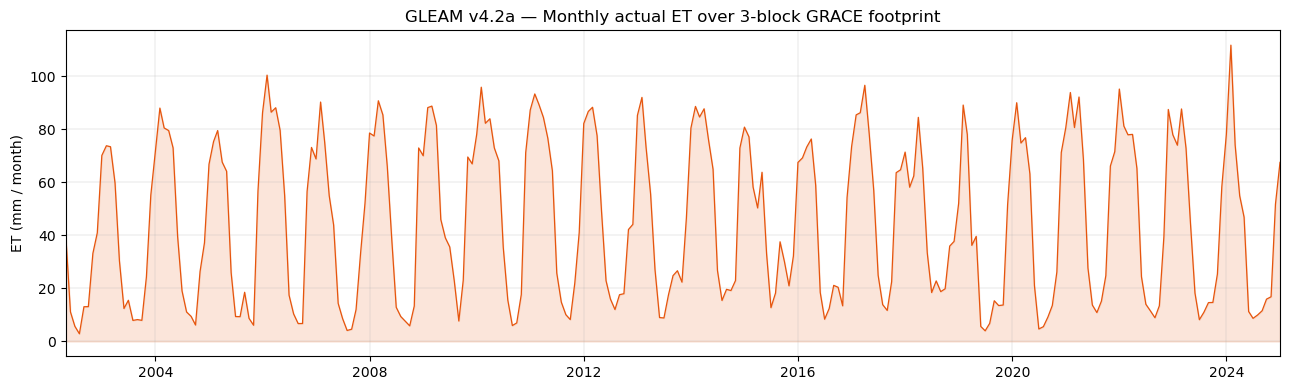

Period: 2002-04-30 → 2024-12-31
Mean: 45.4 mm/month  |  Min: 2.9  |  Max: 111.8


In [10]:
# ── Plot: GLEAM v4.2a monthly ET ──
gleam_sub = df_et_all[df_et_all["dataset"] == "GLEAM_v42a"].copy()

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(gleam_sub["date"], gleam_sub["et_mm_mean"], lw=0.9, color="#e6550d")
ax.fill_between(gleam_sub["date"], 0, gleam_sub["et_mm_mean"],
                alpha=0.15, color="#e6550d")
ax.set_title("GLEAM v4.2a — Monthly actual ET over 3-block GRACE footprint")
ax.set_ylabel("ET (mm / month)")
ax.set_xlim(gleam_sub["date"].min(), gleam_sub["date"].max())
ax.grid(True, lw=0.2)
plt.tight_layout()
plt.show()

print(f"Period: {gleam_sub['date'].min().date()} → {gleam_sub['date'].max().date()}")
print(f"Mean: {gleam_sub['et_mm_mean'].mean():.1f} mm/month  |  "
      f"Min: {gleam_sub['et_mm_mean'].min():.1f}  |  Max: {gleam_sub['et_mm_mean'].max():.1f}")

SSEBop: blanked 46 zero-padded rows (last real: 2022-05-01 00:00:00)
ET models: 8
  ERA5Land_totalET
  FLDAS_Evap
  GLEAM_v42a
  MOD16A2GF_v61
  PML_v2_landET
  TerraClimate_aet
  USGS_SSEBop
  WaPORv3_AETI


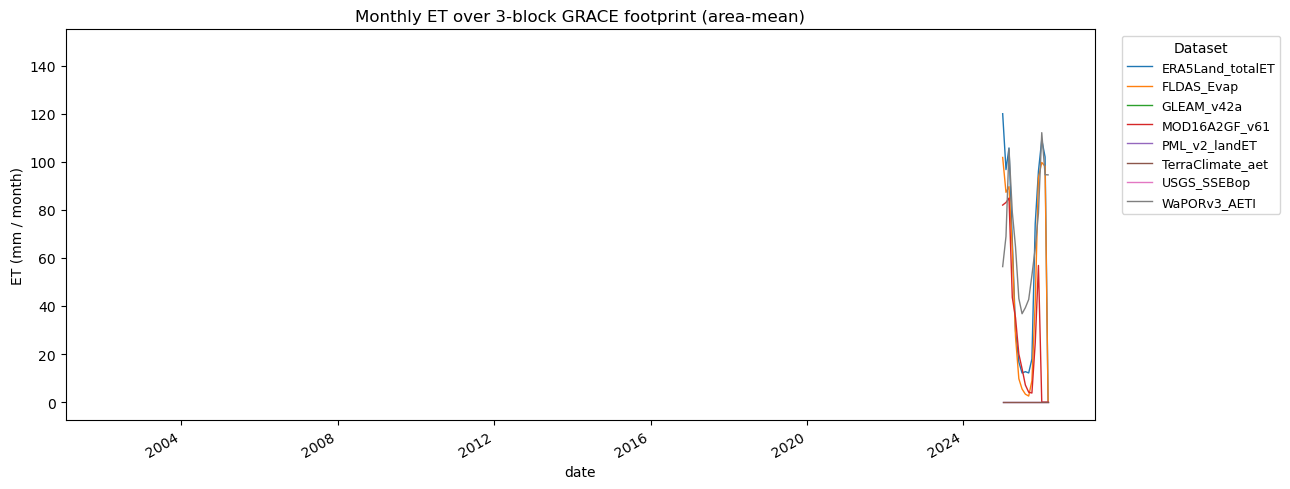

In [11]:
# ── SSEBop zero-padding cleanup ──
ssebop_mask = df_et_all["dataset"].str.contains("SSEBop", case=False)
tiny = 1e-6
if ssebop_mask.any():
    zeros = (df_et_all.loc[ssebop_mask, "et_km3_total"].le(tiny)
             & df_et_all.loc[ssebop_mask, "et_km3_total"].notna())
    if zeros.sum() > 0:
        last_real = df_et_all.loc[ssebop_mask & (df_et_all["et_km3_total"] > tiny), "date"].max()
        df_et_all.loc[ssebop_mask & df_et_all["et_km3_total"].le(tiny), "et_km3_total"] = np.nan
        df_et_all.loc[ssebop_mask & df_et_all["et_mm_mean"].le(tiny),   "et_mm_mean"]   = np.nan
        if pd.notna(last_real):
            df_et_all.loc[ssebop_mask & (df_et_all["date"] > last_real),
                          ["et_km3_total", "et_mm_mean"]] = np.nan
        print(f"SSEBop: blanked {zeros.sum()} zero-padded rows (last real: {last_real})")

print(f"ET models: {df_et_all['dataset'].nunique()}")
for m in sorted(df_et_all["dataset"].unique()):
    print(f"  {m}")

# ── Plot: all ET products (mm/month) ──
wide_et_mm = (df_et_all.pivot_table(index="date", columns="dataset",
                                     values="et_mm_mean", aggfunc="mean")
              .sort_index())

fig, ax = plt.subplots(figsize=(13, 5))
wide_et_mm.plot(ax=ax, linewidth=1)
ax.set_title("Monthly ET over 3-block GRACE footprint (area-mean)")
ax.set_ylabel("ET (mm / month)")
ax.legend(title="Dataset", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

## ET Diagnostic: Delta Polygon vs 3-Block GRACE Domain

In [12]:
print(f"ET models in df_et_all: {sorted(df_et_all['dataset'].unique())}")

ET models in df_et_all: ['ERA5Land_totalET', 'FLDAS_Evap', 'GLEAM_v42a', 'MOD16A2GF_v61', 'PML_v2_landET', 'TerraClimate_aet', 'USGS_SSEBop', 'WaPORv3_AETI']


## 5 — CHIRPS precipitation over 3-block union

In [13]:
CHIRPS_CSV = FIG_DIR / "chirps_monthly.csv"

def make_monthly_precip(daily_ic, band, start_date, end_date):
    start = ee.Date(start_date)
    def month_img(m):
        m = ee.Number(m)
        m0 = start.advance(m, "month")
        m1 = m0.advance(1, "month")
        sub = daily_ic.filterDate(m0, m1).select(band)
        mm = ee.Image(ee.Algorithms.If(sub.size().gt(0), sub.sum(),
                                        ee.Image.constant(0)))
        return (mm.rename("ppt_mm")
                .set({"system:time_start": m0.millis(),
                      "system:index": m0.format("YYYYMM")}))
    months = ee.List(ee.Algorithms.If(
        ee.Date(end_date).difference(start, "month").toInt().gt(0),
        monthly_sequence(start_date, end_date), ee.List([])))
    return ee.ImageCollection.fromImages(months.map(month_img))

def ppt_totals_m3_chunked(ic, region, scale_m=5500, chunk_n=120, tile_scale=8):
    n = int(ic.size().getInfo())
    if n == 0:
        return {}
    imgs = ic.toList(n)
    out = {}
    for i in range(0, n, chunk_n):
        sub = ee.ImageCollection.fromImages(imgs.slice(i, min(i + chunk_n, n)))
        def to_m3(img):
            img = ee.Image(img)
            idx = ee.String(img.get("system:index"))
            return (img.select("ppt_mm").unmask(0)
                    .divide(1000).multiply(ee.Image.pixelArea())
                    .rename("ppt_m3").set("system:index", idx))
        d = sub.map(to_m3).toBands().reduceRegion(
            reducer=ee.Reducer.sum(), geometry=region,
            scale=scale_m, maxPixels=1e13, tileScale=tile_scale).getInfo()
        out.update(d)
    return out

if RUN_EE:
    chirps_daily = (ee.ImageCollection("UCSB-CHG/CHIRPS/DAILY")
                    .filterBounds(block_geom).filterDate(START, END))
    chirps_monthly_ic = make_monthly_precip(chirps_daily, "precipitation", START, END)
    n_p = int(chirps_monthly_ic.size().getInfo())
    print(f"CHIRPS monthly bins: {n_p}")

    ppt_totals = ppt_totals_m3_chunked(chirps_monthly_ic, block_geom)

    rows = []
    for k, v in ppt_totals.items():
        yyyymm = k.split("_")[0]
        date = pd.to_datetime(yyyymm + "01", format="%Y%m%d")
        m3 = float(v) if v is not None else 0.0
        rows.append({"dataset": "CHIRPS_monthly", "date": date,
                      "ppt_km3_total": m3 / 1e9,
                      "ppt_mm_mean": (m3 / block_area_m2) * 1000.0})
    df_chirps = pd.DataFrame(rows).sort_values("date").reset_index(drop=True)
    df_chirps.to_csv(CHIRPS_CSV, index=False)
    print(f"Saved: {CHIRPS_CSV}  ({len(df_chirps)} rows)")
else:
    df_chirps = pd.read_csv(CHIRPS_CSV, parse_dates=["date"])
    print(f"Loaded cached: {CHIRPS_CSV}  ({len(df_chirps)} rows)")

CHIRPS monthly bins: 288
Saved: ../figures/ET comparison/grace_3block/chirps_monthly.csv  (288 rows)


## 6 — GRACE TWS over 3-block union

In [14]:
import re

GRACE_EE_ID = "NASA/GRACE/MASS_GRIDS_V04/MASCON_CRI"
BAND = "lwe_thickness"
GRACE_CSV = FIG_DIR / "grace_monthly.csv"

def grace_totals_m3_chunked(grace_ic, region, scale_m=55660,
                             chunk_n=60, tile_scale=8):
    n = int(grace_ic.size().getInfo())
    if n == 0:
        return {}
    imgs = grace_ic.toList(n)
    out = {}
    def prep(img):
        img = ee.Image(img)
        idx = ee.Date(img.get("system:time_start")).format("YYYYMM")
        return (img.select(BAND).unmask(0)
                .divide(100.0).multiply(ee.Image.pixelArea())
                .rename("tws_m3").set("system:index", idx))
    for i in range(0, n, chunk_n):
        sub = ee.ImageCollection.fromImages(
            imgs.slice(i, min(i + chunk_n, n))).map(prep)
        d = sub.toBands().reduceRegion(
            reducer=ee.Reducer.sum(), geometry=region,
            scale=scale_m, maxPixels=1e13, tileScale=tile_scale).getInfo()
        out.update(d)
    return out

if RUN_EE:
    grace_ic = (ee.ImageCollection(GRACE_EE_ID)
                .filterBounds(block_geom).filterDate(START, END).select(BAND))
    print("GRACE images:", grace_ic.size().getInfo())

    g_totals = grace_totals_m3_chunked(grace_ic, block_geom)

    rows = []
    for k, v in g_totals.items():
        m = re.search(r"(\d{6,8})", k)
        if m is None:
            continue
        code = m.group(1)
        date = pd.to_datetime(code + ("01" if len(code) == 6 else ""),
                               format="%Y%m%d")
        m3 = float(v) if v is not None else 0.0
        rows.append({"date": date,
                      "grace_km3_total": m3 / 1e9,
                      "grace_cm_mean": (m3 / block_area_m2) * 100.0})
    df_grace = pd.DataFrame(rows).sort_values("date").reset_index(drop=True)
    df_grace.to_csv(GRACE_CSV, index=False)
    print(f"Saved: {GRACE_CSV}  ({len(df_grace)} rows)")
else:
    df_grace = pd.read_csv(GRACE_CSV, parse_dates=["date"])
    print(f"Loaded cached: {GRACE_CSV}  ({len(df_grace)} rows)")

GRACE images: 238
Saved: ../figures/ET comparison/grace_3block/grace_monthly.csv  (238 rows)


## 6b — NW block GRACE TWS (for lateral-flux terms)

Extract the **NW** mascon block time series from the local GRACE netCDF to form
two lateral-flux proxies:

| Proxy | Gradient | Physical interpretation |
|-------|----------|------------------------|
| $\Delta_1$ | TWS$_{\text{NW}}$ − TWS$_{\text{NE}}$ | West→east flow across the NE block boundary |
| $\Delta_2$ | TWS$_{\text{SW}}$ − TWS$_{\text{NW}}$ | South→north gradient driving flow into the domain from the SW |

NW block: B009  lon 18.00–19.00  lat -19.50–-16.50
NE block: B011  lon 22.00–25.50  lat -19.50–-16.50
SW block: B006  lon 19.50–22.50  lat -22.50–-19.50


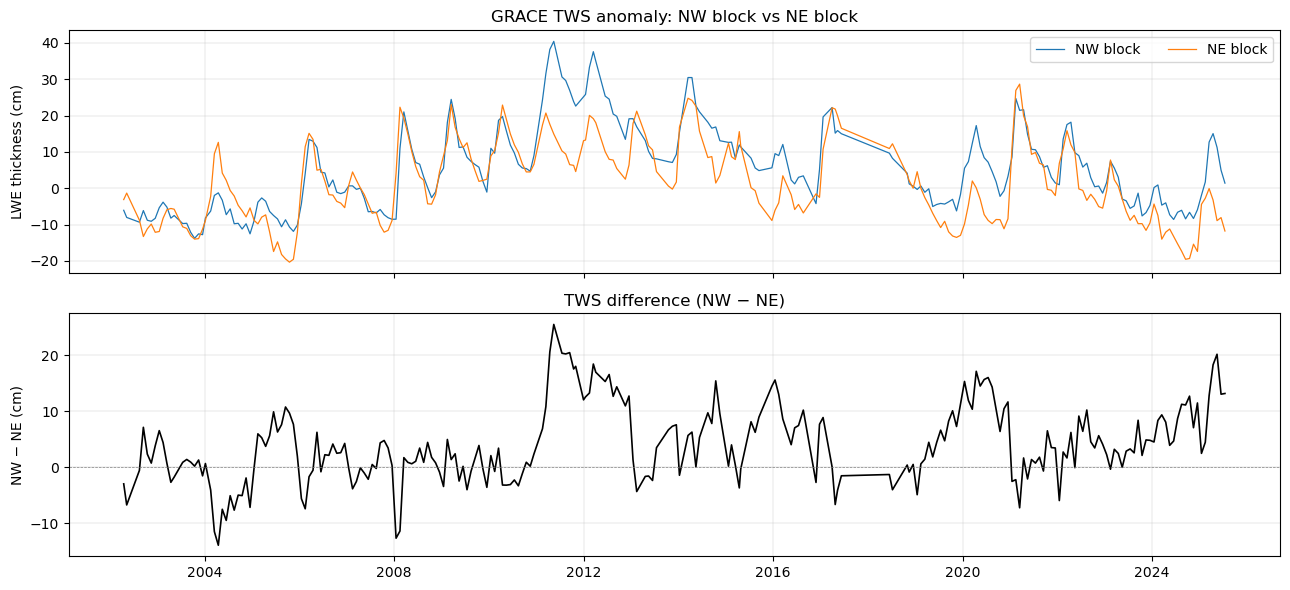


Mean NW−NE: 3.99 cm
Std  NW−NE: 6.79 cm


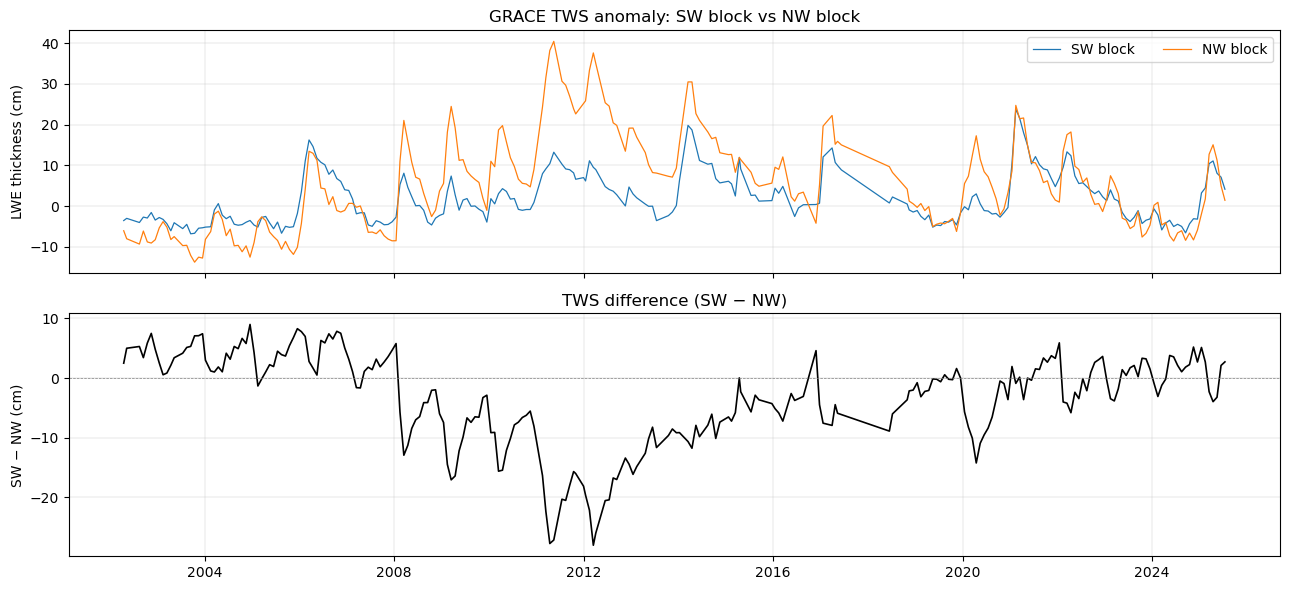


Mean SW−NW: -3.23 cm
Std  SW−NW: 7.62 cm


In [15]:
# ── NW block GRACE TWS (for tunable lateral-flux terms) ──
# Find the NW block (excluded from USE_BLOCKS but present in `blocks`)
NW_BLOCK = [b for b in blocks if b["quadrant"] == "NW"]
assert NW_BLOCK, "No NW block found in discovered mascon blocks"
NW_BLOCK = NW_BLOCK[0]

ne_b = [b for b in USE_BLOCKS if b["quadrant"] == "NE"][0]
sw_b = [b for b in USE_BLOCKS if b["quadrant"] == "SW"][0]

print(f"NW block: {NW_BLOCK['block_id']}  "
      f"lon {NW_BLOCK['lon0']:.2f}–{NW_BLOCK['lon1']:.2f}  "
      f"lat {NW_BLOCK['lat0']:.2f}–{NW_BLOCK['lat1']:.2f}")
print(f"NE block: {ne_b['block_id']}  "
      f"lon {ne_b['lon0']:.2f}–{ne_b['lon1']:.2f}  "
      f"lat {ne_b['lat0']:.2f}–{ne_b['lat1']:.2f}")
print(f"SW block: {sw_b['block_id']}  "
      f"lon {sw_b['lon0']:.2f}–{sw_b['lon1']:.2f}  "
      f"lat {sw_b['lat0']:.2f}–{sw_b['lat1']:.2f}")

# ── Extract time series from local GRACE netCDF ──
ds_g_nw = xr.open_dataset(GRACE_NC)
da_lwe_nw = ds_g_nw["lwe_thickness"]

nw_clat = (NW_BLOCK["lat0"] + NW_BLOCK["lat1"]) / 2
nw_clon = (NW_BLOCK["lon0"] + NW_BLOCK["lon1"]) / 2
nw_tws = da_lwe_nw.sel(lat=nw_clat, lon=nw_clon, method="nearest").values

ne_clat = (ne_b["lat0"] + ne_b["lat1"]) / 2
ne_clon = (ne_b["lon0"] + ne_b["lon1"]) / 2
ne_tws = da_lwe_nw.sel(lat=ne_clat, lon=ne_clon, method="nearest").values

sw_clat = (sw_b["lat0"] + sw_b["lat1"]) / 2
sw_clon = (sw_b["lon0"] + sw_b["lon1"]) / 2
sw_tws = da_lwe_nw.sel(lat=sw_clat, lon=sw_clon, method="nearest").values

times_nw = pd.to_datetime(da_lwe_nw["time"].values)
ds_g_nw.close()

# NW − NE difference
df_nw_ne = pd.DataFrame({
    "date": times_nw,
    "TWS_NW_cm": nw_tws,
    "TWS_NE_cm": ne_tws,
})
df_nw_ne["NW_NE_diff_cm"] = df_nw_ne["TWS_NW_cm"] - df_nw_ne["TWS_NE_cm"]

# SW − NW difference (positive when SW head > NW → drives inflow into domain)
df_sw_nw = pd.DataFrame({
    "date": times_nw,
    "TWS_SW_cm": sw_tws,
    "TWS_NW_cm": nw_tws,
})
df_sw_nw["SW_NW_diff_cm"] = df_sw_nw["TWS_SW_cm"] - df_sw_nw["TWS_NW_cm"]

# ── Plot NW−NE ──
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 6), sharex=True)

ax1.plot(df_nw_ne["date"], df_nw_ne["TWS_NW_cm"], lw=0.9, label="NW block")
ax1.plot(df_nw_ne["date"], df_nw_ne["TWS_NE_cm"], lw=0.9, label="NE block")
ax1.set_ylabel("LWE thickness (cm)")
ax1.set_title("GRACE TWS anomaly: NW block vs NE block")
ax1.legend(ncol=2)
ax1.grid(True, lw=0.2)

ax2.plot(df_nw_ne["date"], df_nw_ne["NW_NE_diff_cm"], lw=1.2, color="k")
ax2.axhline(0, lw=0.5, color="0.5", ls="--")
ax2.set_ylabel("NW − NE (cm)")
ax2.set_title("TWS difference (NW − NE)")
ax2.grid(True, lw=0.2)

plt.tight_layout()
plt.show()

print(f"\nMean NW−NE: {df_nw_ne['NW_NE_diff_cm'].mean():.2f} cm")
print(f"Std  NW−NE: {df_nw_ne['NW_NE_diff_cm'].std():.2f} cm")

# ── Plot SW−NW ──
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 6), sharex=True)

ax1.plot(df_sw_nw["date"], df_sw_nw["TWS_SW_cm"], lw=0.9, label="SW block")
ax1.plot(df_sw_nw["date"], df_sw_nw["TWS_NW_cm"], lw=0.9, label="NW block")
ax1.set_ylabel("LWE thickness (cm)")
ax1.set_title("GRACE TWS anomaly: SW block vs NW block")
ax1.legend(ncol=2)
ax1.grid(True, lw=0.2)

ax2.plot(df_sw_nw["date"], df_sw_nw["SW_NW_diff_cm"], lw=1.2, color="k")
ax2.axhline(0, lw=0.5, color="0.5", ls="--")
ax2.set_ylabel("SW − NW (cm)")
ax2.set_title("TWS difference (SW − NW)")
ax2.grid(True, lw=0.2)

plt.tight_layout()
plt.show()

print(f"\nMean SW−NW: {df_sw_nw['SW_NW_diff_cm'].mean():.2f} cm")
print(f"Std  SW−NW: {df_sw_nw['SW_NW_diff_cm'].std():.2f} cm")

## 7 — Mohembo inflow

Mohembo gap-fill: 4 months filled (4 → 0 NaN)
Mohembo rows: 591
Range: 1974-12-01 → 2024-02-01


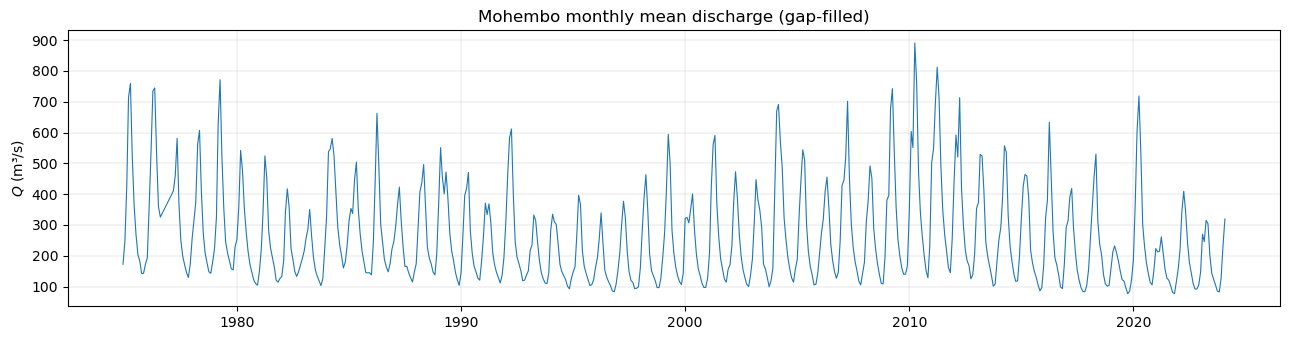

In [16]:
monthly = pd.read_csv(MOHEMBO_MONTHLY, parse_dates=["month"])

# Convert Q (m³/s) → volume per month
monthly["days_in_month"] = monthly["month"].dt.days_in_month
monthly["Qin_m3s"] = monthly["Q_m3s_monthly_mean"]
monthly["Qin_km3"] = monthly["Qin_m3s"] * monthly["days_in_month"] * 86400 / 1e9
monthly["Qin_mm"]  = monthly["Qin_km3"] * 1e9 / block_area_m2 * 1000.0
monthly = monthly.rename(columns={"month": "date"})
q_mohembo = monthly[["date", "Qin_m3s", "Qin_km3", "Qin_mm"]].copy()

# ── 2nd-order polynomial gap-fill (gaps ≤ 2 months) ─────────────────────────
before_na = int(q_mohembo["Qin_m3s"].isna().sum())

for col in ["Qin_m3s"]:
    s = q_mohembo[col].copy()
    is_nan = s.isna()
    gap_id = (~is_nan).cumsum()
    gap_len = is_nan.groupby(gap_id).transform("sum")

    # Use positional index to avoid duplicate-x errors
    filled = (
        s.reset_index(drop=True)
         .interpolate(method="polynomial", order=2, limit_direction="forward")
    )
    filled.index = s.index
    filled[is_nan & (gap_len > 2)] = np.nan
    q_mohembo[col] = filled

# Recompute derived columns from gap-filled Qin_m3s
q_mohembo["Qin_km3"] = (q_mohembo["Qin_m3s"]
                         * monthly["days_in_month"].values * 86400 / 1e9)
q_mohembo["Qin_mm"]  = q_mohembo["Qin_km3"] * 1e9 / block_area_m2 * 1000.0

after_na = int(q_mohembo["Qin_m3s"].isna().sum())
print(f"Mohembo gap-fill: {before_na - after_na} months filled "
      f"({before_na} → {after_na} NaN)")

print(f"Mohembo rows: {len(q_mohembo)}")
print(f"Range: {q_mohembo['date'].min().date()} → {q_mohembo['date'].max().date()}")

fig, ax = plt.subplots(figsize=(13, 3.5))
ax.plot(q_mohembo["date"], q_mohembo["Qin_m3s"], lw=0.8)
ax.set_title("Mohembo monthly mean discharge (gap-filled)")
ax.set_ylabel(r"$Q$ (m³/s)")
ax.grid(True, lw=0.2)
plt.tight_layout()
plt.show()

## 8 — Mass-balance assembly

In [17]:
def to_month_start(s):
    return pd.to_datetime(s).dt.to_period("M").dt.to_timestamp("s")

# Normalize all dates to month-start
df_et_all = df_et_all.copy()
df_et_all["date"] = to_month_start(df_et_all["date"])
df_chirps["date"] = to_month_start(df_chirps["date"])
df_grace["date"]  = to_month_start(df_grace["date"])
q_mohembo["date"] = to_month_start(q_mohembo["date"])
df_nw_ne_m = df_nw_ne.copy()
df_nw_ne_m["date"] = to_month_start(df_nw_ne_m["date"])
df_sw_nw_m = df_sw_nw.copy()
df_sw_nw_m["date"] = to_month_start(df_sw_nw_m["date"])

# Collapse any duplicate months
df_et_all  = df_et_all.groupby(["date", "dataset"], as_index=False).mean(numeric_only=True)
df_chirps  = df_chirps.groupby(["date", "dataset"], as_index=False).mean(numeric_only=True)
df_grace   = df_grace.groupby("date", as_index=False).mean(numeric_only=True)
q_mohembo  = q_mohembo.groupby("date", as_index=False).mean(numeric_only=True)
df_nw_ne_m = df_nw_ne_m.groupby("date", as_index=False).mean(numeric_only=True)
df_sw_nw_m = df_sw_nw_m.groupby("date", as_index=False).mean(numeric_only=True)

# 1) ET ensemble median
et_km3_wide = (df_et_all.pivot_table(index="date", columns="dataset",
                                      values="et_km3_total", aggfunc="median")
               .sort_index())
et_mm_wide = (df_et_all.pivot_table(index="date", columns="dataset",
                                     values="et_mm_mean", aggfunc="median")
              .sort_index())
ETmm_med  = et_mm_wide.median(axis=1, skipna=True).rename("ETmm")
ETkm3_med = et_km3_wide.median(axis=1, skipna=True).rename("ETkm3")

# 2) CHIRPS
p_ser = df_chirps.set_index("date")
Pmm   = p_ser["ppt_mm_mean"].rename("Pmm")
Pkm3  = p_ser["ppt_km3_total"].rename("Pkm3")

# 3) GRACE storage anomaly + monthly ΔS
gr = (df_grace.set_index("date")
      [["grace_cm_mean", "grace_km3_total"]]
      .sort_index()
      .rename(columns={"grace_cm_mean": "GRACEcm", "grace_km3_total": "GRACEkm3"}))
dS_km3 = gr["GRACEkm3"].diff().rename("dS_km3")
dS_cm  = gr["GRACEcm"].diff().rename("dS_cm")

gap_days = gr.index.to_series().diff().dt.days
n_gaps = int((gap_days > 45).sum())
if n_gaps > 0:
    print(f"GRACE gaps > 45 days: {n_gaps} — setting ΔS to NaN across those.")
    dS_km3[gap_days > 45] = np.nan
    dS_cm[gap_days > 45]  = np.nan

# 4) Qin
qin = q_mohembo.set_index("date")[["Qin_m3s", "Qin_km3", "Qin_mm"]].sort_index()

# 4b) NW−NE GRACE TWS difference (for tunable lateral-flux term)
nw_ne = df_nw_ne_m.set_index("date")["NW_NE_diff_cm"].sort_index()
# 4c) SW−NW GRACE TWS difference (for tunable lateral-flux term)
sw_nw = df_sw_nw_m.set_index("date")["SW_NW_diff_cm"].sort_index()

# 5) Combine
df_balance = pd.concat([Pmm, Pkm3, ETmm_med, ETkm3_med,
                         gr, dS_km3, dS_cm, qin, nw_ne, sw_nw], axis=1).sort_index()

# Residual: Qout + G ≈ Qin + P − ET − ΔS
df_balance["Qout_G_km3"] = (df_balance["Qin_km3"] + df_balance["Pkm3"]
                             - df_balance["ETkm3"] - df_balance["dS_km3"])
df_balance["has_closure"] = (df_balance[["Qin_km3", "Pkm3", "ETkm3", "dS_km3"]]
                             .notna().all(axis=1))

df_balance = df_balance.loc[df_balance.index >= "2002-04-01"].copy()
print(f"Balance table: {len(df_balance)} months, "
      f"{df_balance['has_closure'].sum()} with full closure data")
print(f"NW_NE_diff_cm available: {df_balance['NW_NE_diff_cm'].notna().sum()} months")
print(f"SW_NW_diff_cm available: {df_balance['SW_NW_diff_cm'].notna().sum()} months")
df_balance.head(10)

GRACE gaps > 45 days: 21 — setting ΔS to NaN across those.
Balance table: 288 months, 198 with full closure data
NW_NE_diff_cm available: 245 months
SW_NW_diff_cm available: 245 months


,Pmm,Pkm3,ETmm,ETkm3,GRACEcm,GRACEkm3,dS_km3,dS_cm,Qin_m3s,Qin_km3,Qin_mm,NW_NE_diff_cm,SW_NW_diff_cm,Qout_G_km3,has_closure
date,,,,,,,,,,,,,,,
2002-04-01,22.770576,7.543119,38.165946,12.641958,-2.659414,-8.809735,NaN,NaN,472.675333,1.225174,3.698461,-2.941969,2.495819,NaN,False
2002-05-01,0.226415,0.075004,10.857336,3.596348,-1.288712,-4.269065,4.540670,1.370702,388.285484,1.039984,3.139422,-6.701625,5.003813,-7.022030,True
2002-06-01,0.010150,0.003362,6.490554,2.149936,NaN,NaN,NaN,NaN,270.247667,0.700482,2.114560,NaN,NaN,NaN,False
2002-07-01,0.015582,0.005162,4.006239,1.327048,-5.564862,-18.434498,NaN,NaN,199.344516,0.533924,1.611769,NaN,NaN,NaN,False
2002-08-01,0.289313,0.095839,6.365648,2.108723,-6.840002,-22.658604,-4.224107,-1.275140,155.478065,0.416432,1.257094,-0.545197,5.296357,2.627655,True
2002-09-01,2.345674,0.777042,10.631638,3.521901,-5.930015,-19.644127,3.014477,0.909987,128.508000,0.333093,1.005514,7.143593,3.425695,-5.426243,True
2002-10-01,23.369019,7.741363,26.898204,8.910462,-4.614847,-15.287423,4.356705,1.315168,107.130968,0.286940,0.866191,2.361340,5.867341,-5.238864,True
2002-11-01,46.588140,15.433069,40.361449,13.369204,-6.564019,-21.744368,-6.456945,-1.949172,100.049667,0.259329,0.782841,0.761246,7.497902,8.780140,True
2002-12-01,77.574902,25.697932,73.252830,24.264165,-6.407135,-21.224664,0.519704,0.156884,136.228065,0.364873,1.101451,3.843057,4.826894,1.278936,True


## 9 — Mass-balance plots

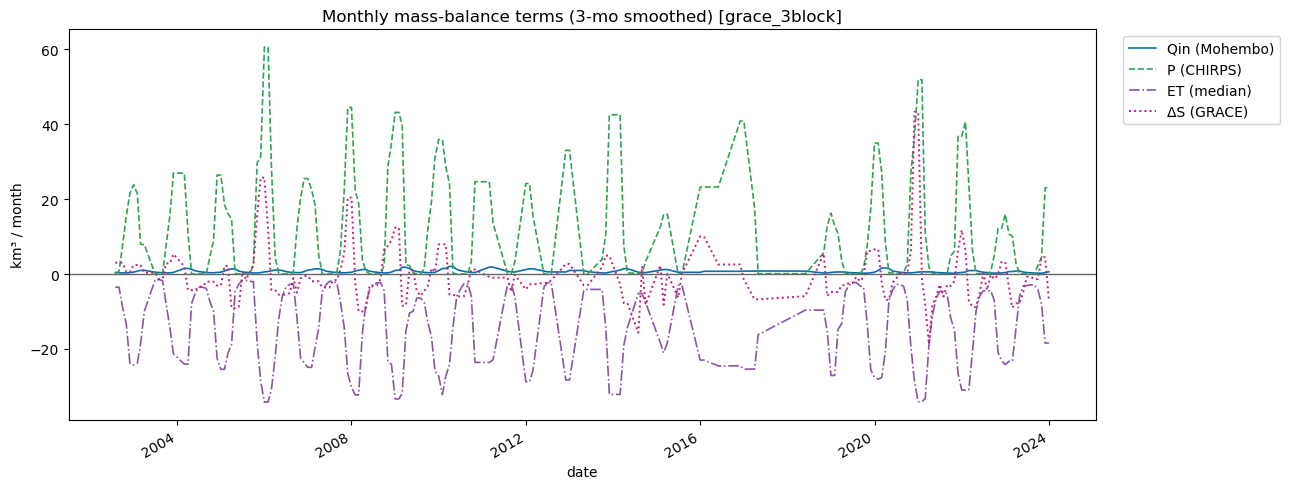

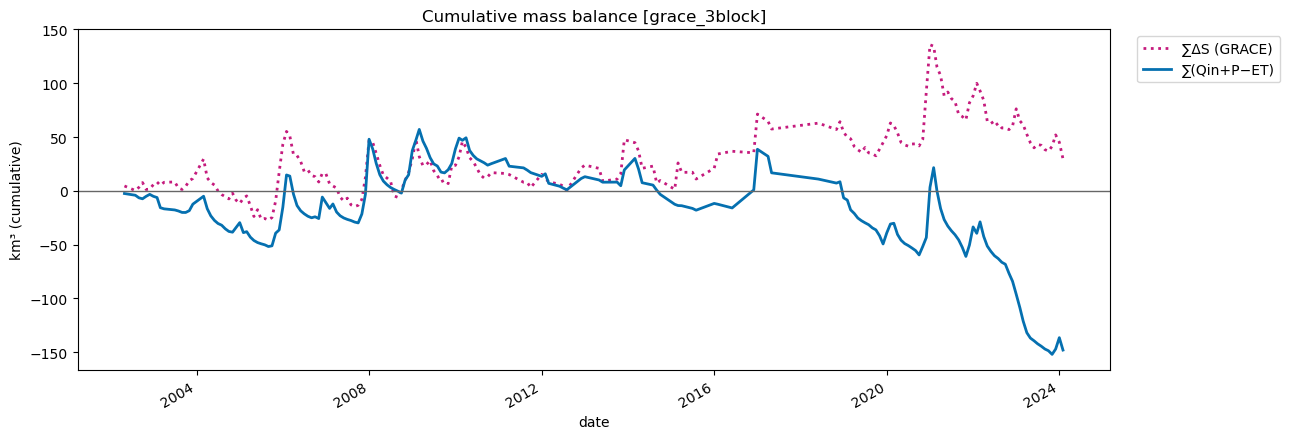

In [18]:
TERM_STYLE = {
    "Qin (Mohembo)": {"color": "#0570b0", "ls": "-",  "lw": 1.2},
    "P (CHIRPS)":    {"color": "#31a354", "ls": "--", "lw": 1.2},
    "ET (median)":   {"color": "#8856a7", "ls": "-.", "lw": 1.2},
    "ΔS (GRACE)":    {"color": "#c51b7d", "ls": ":",  "lw": 1.4},
}

dfc = df_balance[df_balance["has_closure"]].copy()

# ── Plot 1: monthly terms (3-mo smoothed) ──
plot_terms = pd.DataFrame(index=dfc.index)
plot_terms["Qin (Mohembo)"] = dfc["Qin_km3"]
plot_terms["P (CHIRPS)"]    = dfc["Pkm3"]
plot_terms["ET (median)"]   = -dfc["ETkm3"]
plot_terms["ΔS (GRACE)"]    = dfc["dS_km3"]

fig, ax = plt.subplots(figsize=(13, 5))
for col in plot_terms.columns:
    sty = TERM_STYLE[col]
    plot_terms[col].rolling(3, center=True).median().plot(
        ax=ax, color=sty["color"], ls=sty["ls"], lw=sty["lw"], label=col)
ax.axhline(0, lw=1, c="0.4")
ax.set_title(f"Monthly mass-balance terms (3-mo smoothed) [{GEOM_TAG}]")
ax.set_ylabel("km³ / month")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
fig.savefig(FIG_DIR / "mass_balance_terms.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Plot 2: cumulative ──
cum = pd.DataFrame(index=dfc.index)
cum["∑ΔS (GRACE)"]   = dfc["dS_km3"].cumsum()
cum["∑(Qin+P−ET)"]   = (dfc["Qin_km3"] + dfc["Pkm3"] - dfc["ETkm3"]).cumsum()

fig, ax = plt.subplots(figsize=(13, 4.5))
cum["∑ΔS (GRACE)"].plot(ax=ax, color="#c51b7d", ls=":", lw=2, label="∑ΔS (GRACE)")
cum["∑(Qin+P−ET)"].plot(ax=ax, color="#0570b0", ls="-", lw=2, label="∑(Qin+P−ET)")
ax.axhline(0, lw=1, c="0.4")
ax.set_title(f"Cumulative mass balance [{GEOM_TAG}]")
ax.set_ylabel("km³ (cumulative)")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
fig.savefig(FIG_DIR / "cumulative_sums.png", dpi=150, bbox_inches="tight")
plt.show()

## 10 — Per-ET-model cumulative plots

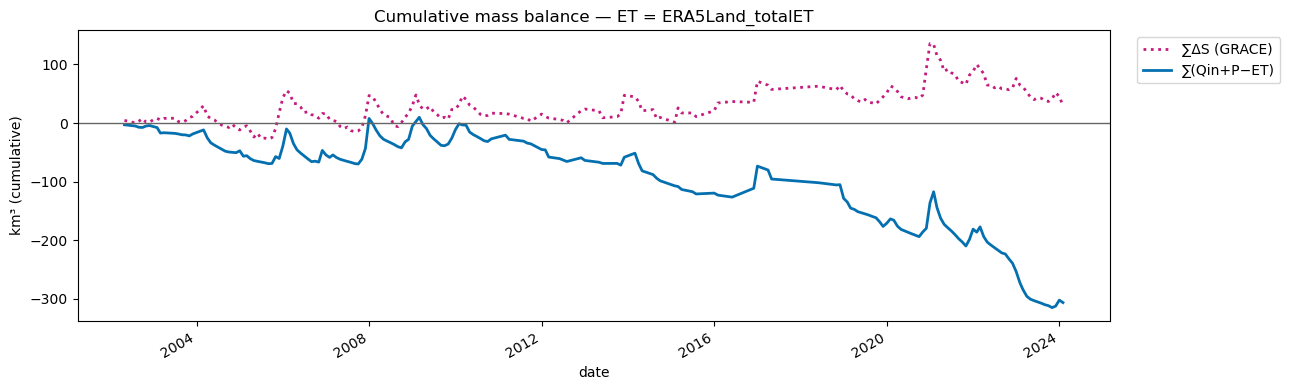

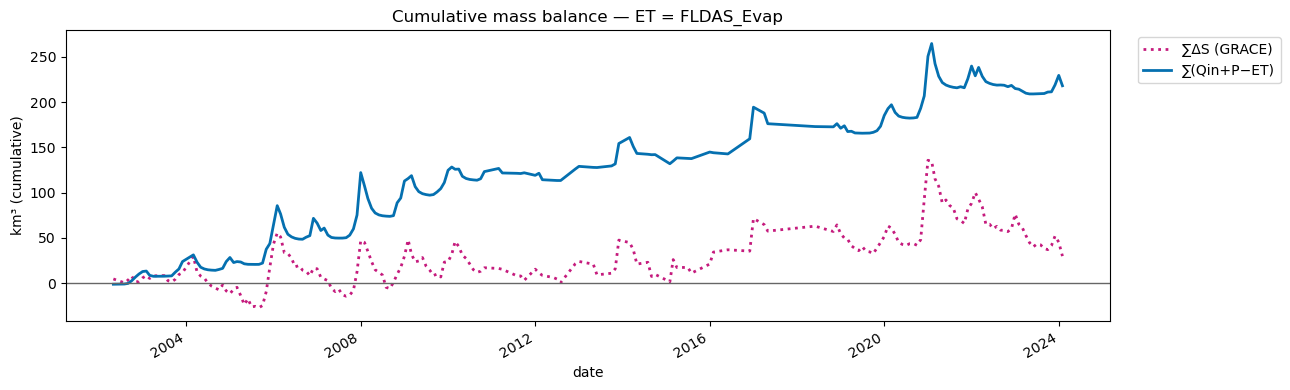

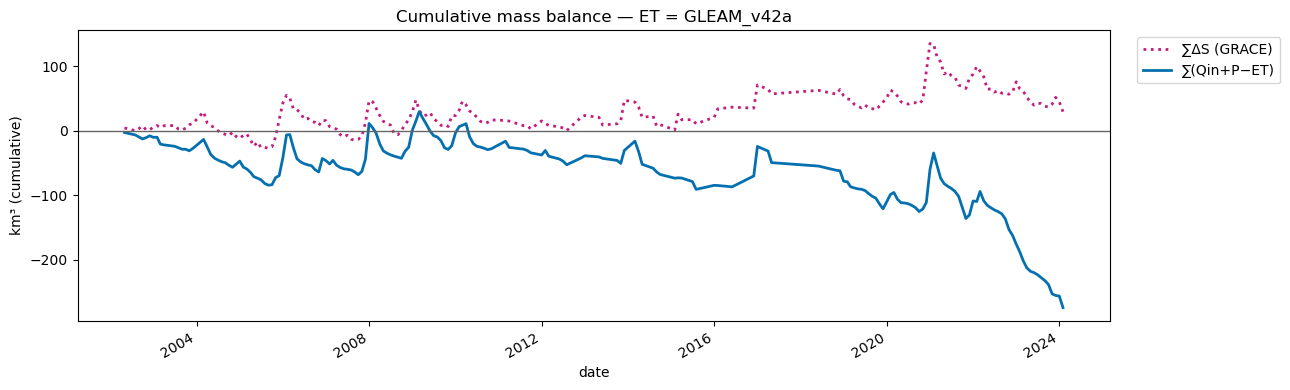

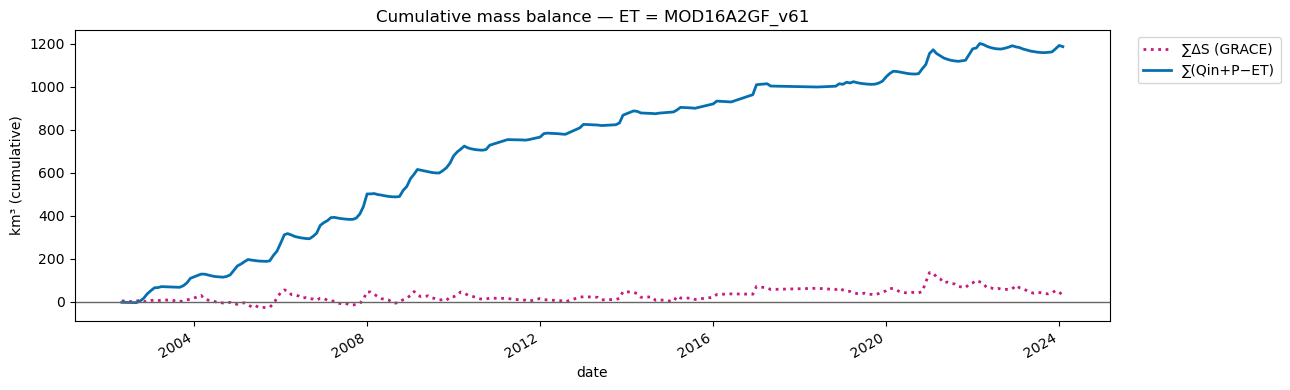

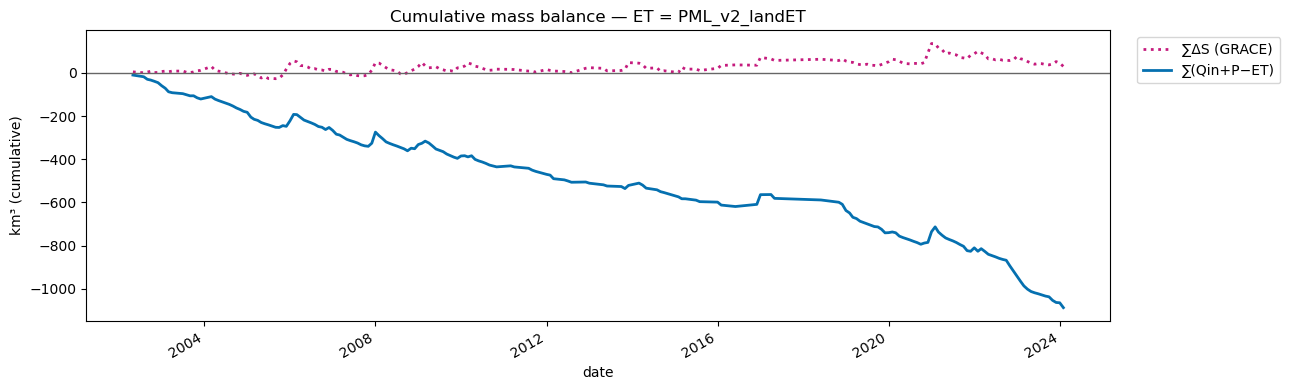

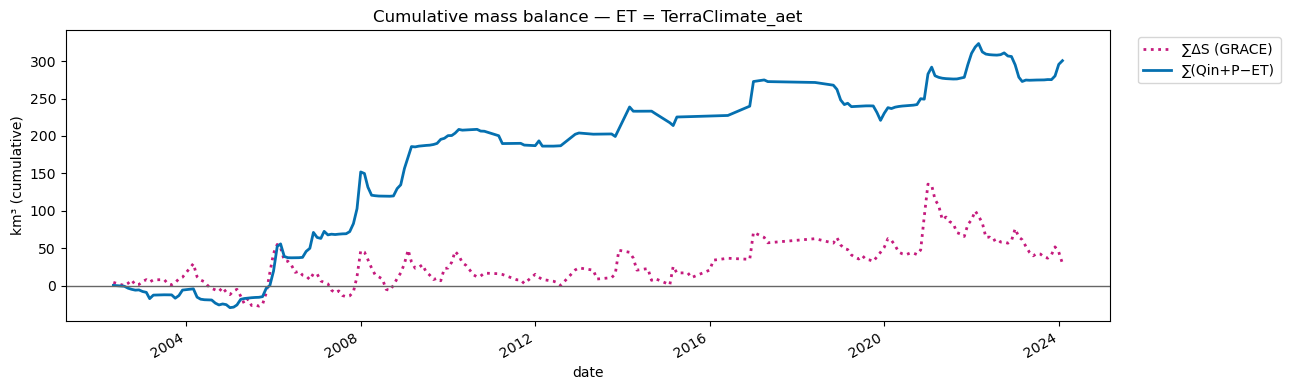

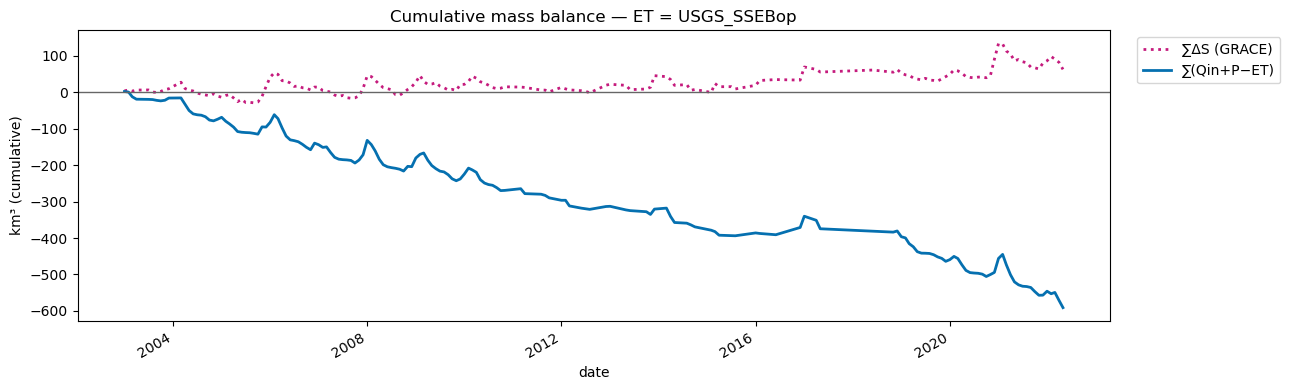

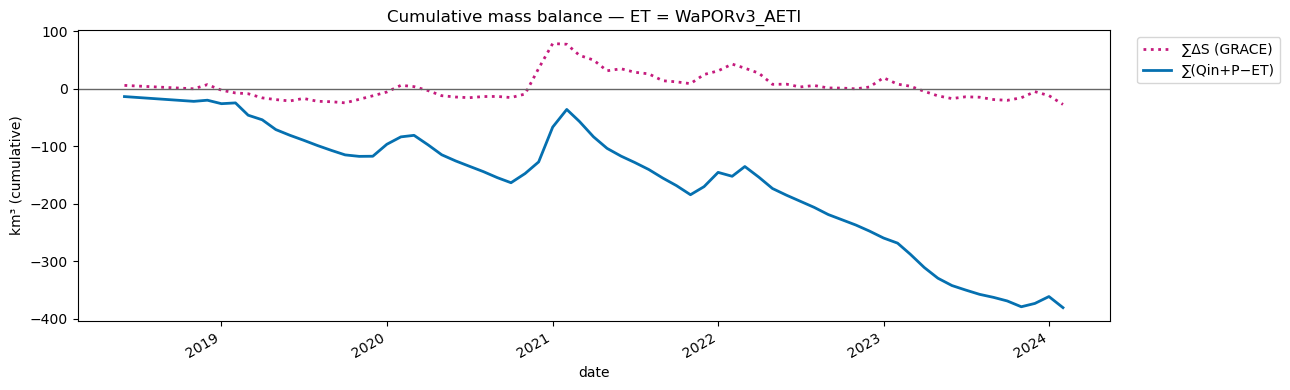

In [20]:
base_mask = df_balance[["Qin_km3", "Pkm3", "dS_km3"]].notna().all(axis=1)
dfc_base = df_balance.loc[base_mask].copy()

et_km3_aligned = et_km3_wide.reindex(dfc_base.index)

for et_name in et_km3_aligned.columns:
    dfc = dfc_base.copy()
    dfc["ETkm3_model"] = et_km3_aligned[et_name]
    dfc = dfc[dfc["ETkm3_model"].notna()]
    if len(dfc) < 6:
        continue

    cum = pd.DataFrame(index=dfc.index)
    cum["∑ΔS (GRACE)"] = dfc["dS_km3"].cumsum()
    cum[f"∑(Qin+P−ET)"] = (dfc["Qin_km3"] + dfc["Pkm3"] - dfc["ETkm3_model"]).cumsum()

    fig, ax = plt.subplots(figsize=(13, 4))
    cum["∑ΔS (GRACE)"].plot(ax=ax, color="#c51b7d", ls=":", lw=2, label="∑ΔS (GRACE)")
    cum["∑(Qin+P−ET)"].plot(ax=ax, color="#0570b0", ls="-", lw=2, label="∑(Qin+P−ET)")
    ax.axhline(0, lw=1, c="0.4")
    ax.set_title(f"Cumulative mass balance — ET = {et_name}")
    ax.set_ylabel("km³ (cumulative)")
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()

    slug = et_name.replace("/", "_").replace(" ", "_")
    model_dir = FIG_DIR / "single-model" / slug
    model_dir.mkdir(parents=True, exist_ok=True)
    fig.savefig(model_dir / "cumulative_sums.png", dpi=150, bbox_inches="tight")
    plt.show()

## 10b — Tunable lateral-flux term: α × (TWS_NW − TWS_NE)

Modified budget: $Q_{\text{in}} + P - ET + \alpha\,(S_{\text{NW}} - S_{\text{NE}}) \approx \Delta S$

The TWS gradient between the NW mascon block and the NE block acts as a proxy
for lateral (groundwater / diffuse surface) inflow not captured by the Mohembo
gauge.  For each ET model, $\alpha$ is optimised to minimise
$\sum\bigl[\text{cum}(Q_\text{in}+P-ET+\alpha\,\Delta_{\text{NW-NE}}) - \text{cum}(\Delta S)\bigr]^2$.

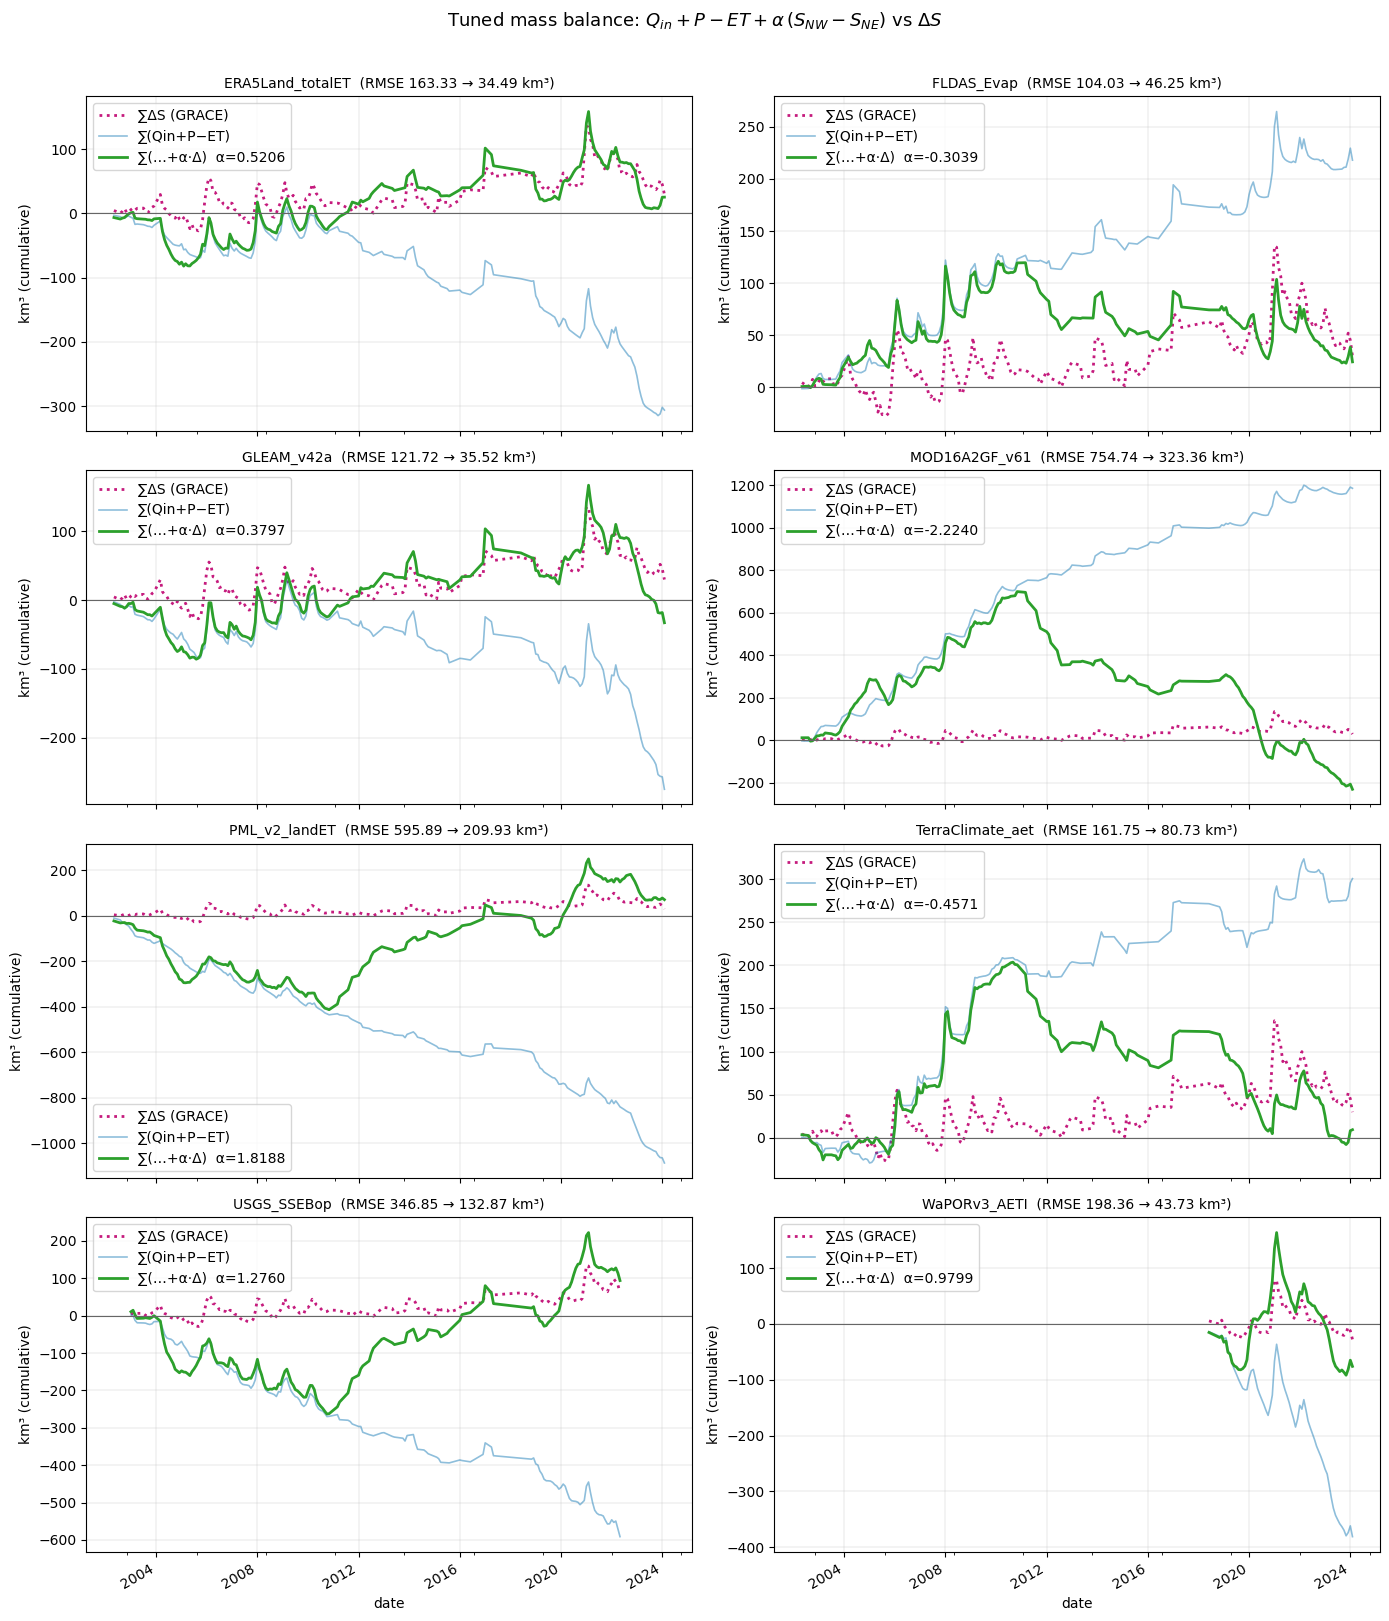


── Optimal α per ET model ──
        ET_model   alpha  RMSE_base_km3  RMSE_tuned_km3  improvement_pct
ERA5Land_totalET  0.5206       163.3262         34.4864          78.8849
    WaPORv3_AETI  0.9799       198.3631         43.7287          77.9552
      GLEAM_v42a  0.3797       121.7171         35.5174          70.8197
   PML_v2_landET  1.8188       595.8920        209.9279          64.7708
     USGS_SSEBop  1.2760       346.8493        132.8748          61.6909
   MOD16A2GF_v61 -2.2240       754.7361        323.3631          57.1555
      FLDAS_Evap -0.3039       104.0336         46.2481          55.5450
TerraClimate_aet -0.4571       161.7495         80.7295          50.0898


In [21]:
# ── Tunable lateral-flux term: α × (TWS_NW − TWS_NE) ──
# Modified budget: Qin + P − ET + α·(NW−NE) ≈ ΔS
# Optimise α per ET model to minimise ∑[cum(budget) − cum(ΔS)]²

base_mask_t = df_balance[["Qin_km3", "Pkm3", "dS_km3", "NW_NE_diff_cm"]].notna().all(axis=1)
dfc_tune = df_balance.loc[base_mask_t].copy()
et_tune = et_km3_wide.reindex(dfc_tune.index)

# ── Pass 1: compute optimal α per ET model ──
results = []
plot_data = {}
for et_name in sorted(et_tune.columns):
    dfc = dfc_tune.copy()
    dfc["ETkm3_model"] = et_tune[et_name]
    dfc = dfc[dfc["ETkm3_model"].notna()]
    if len(dfc) < 6:
        continue

    flux = dfc["Qin_km3"] + dfc["Pkm3"] - dfc["ETkm3_model"]
    ds_obs = dfc["dS_km3"]
    x = dfc["NW_NE_diff_cm"]

    cum_resid = (flux - ds_obs).cumsum().values
    cum_x = x.cumsum().values
    valid = ~(np.isnan(cum_resid) | np.isnan(cum_x))
    alpha_opt = -np.dot(cum_resid[valid], cum_x[valid]) / np.dot(cum_x[valid], cum_x[valid])

    cum_ds = ds_obs.cumsum()
    cum_base = flux.cumsum()
    cum_tuned = (flux + alpha_opt * x).cumsum()

    rmse_base = np.sqrt(np.nanmean((cum_base.values - cum_ds.values) ** 2))
    rmse_tune = np.sqrt(np.nanmean((cum_tuned.values - cum_ds.values) ** 2))
    improv = (1 - rmse_tune / rmse_base) * 100 if rmse_base > 0 else 0
    results.append({"ET_model": et_name, "alpha": alpha_opt,
                    "RMSE_base_km3": rmse_base, "RMSE_tuned_km3": rmse_tune,
                    "improvement_pct": improv})
    plot_data[et_name] = dict(cum_ds=cum_ds, cum_base=cum_base,
                              cum_tuned=cum_tuned, alpha=alpha_opt,
                              rmse_base=rmse_base, rmse_tune=rmse_tune)

df_results = pd.DataFrame(results).sort_values("improvement_pct", ascending=False)
all_et = df_results["ET_model"].tolist()
n_models = len(all_et)
ncols = 2
nrows = (n_models + ncols - 1) // ncols

# ── Pass 2: plot ranked best → worst ──
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows), sharex=True)
axes = axes.flatten()

for i, et_name in enumerate(all_et):
    ax = axes[i]
    d = plot_data[et_name]
    d["cum_ds"].plot(ax=ax, color="#c51b7d", ls=":", lw=2, label="∑ΔS (GRACE)")
    d["cum_base"].plot(ax=ax, color="#0570b0", ls="-", lw=1.2, alpha=0.45,
                       label="∑(Qin+P−ET)")
    d["cum_tuned"].plot(ax=ax, color="#2ca02c", ls="-", lw=2,
                        label=f"∑(…+α·Δ)  α={d['alpha']:.4f}")
    ax.axhline(0, lw=0.8, c="0.4")
    ax.set_title(f"{et_name}  (RMSE {d['rmse_base']:.2f} → {d['rmse_tune']:.2f} km³)",
                 fontsize=10)
    ax.set_ylabel("km³ (cumulative)")
    ax.grid(True, lw=0.2)
    ax.legend(fontsize=10, loc="best")

for j in range(n_models, len(axes)):
    axes[j].set_visible(False)

fig.suptitle(r"Tuned mass balance: $Q_{in}+P-ET+\alpha\,(S_{NW}-S_{NE})$ vs $\Delta S$",
             fontsize=13, y=1.01)
plt.tight_layout()
fig.savefig(FIG_DIR / "tuned_alpha_cumulative.png", dpi=180, bbox_inches="tight")
plt.show()

# Summary table
print("\n── Optimal α per ET model (ranked by improvement) ──")
print(df_results.to_string(index=False, float_format="%.4f"))

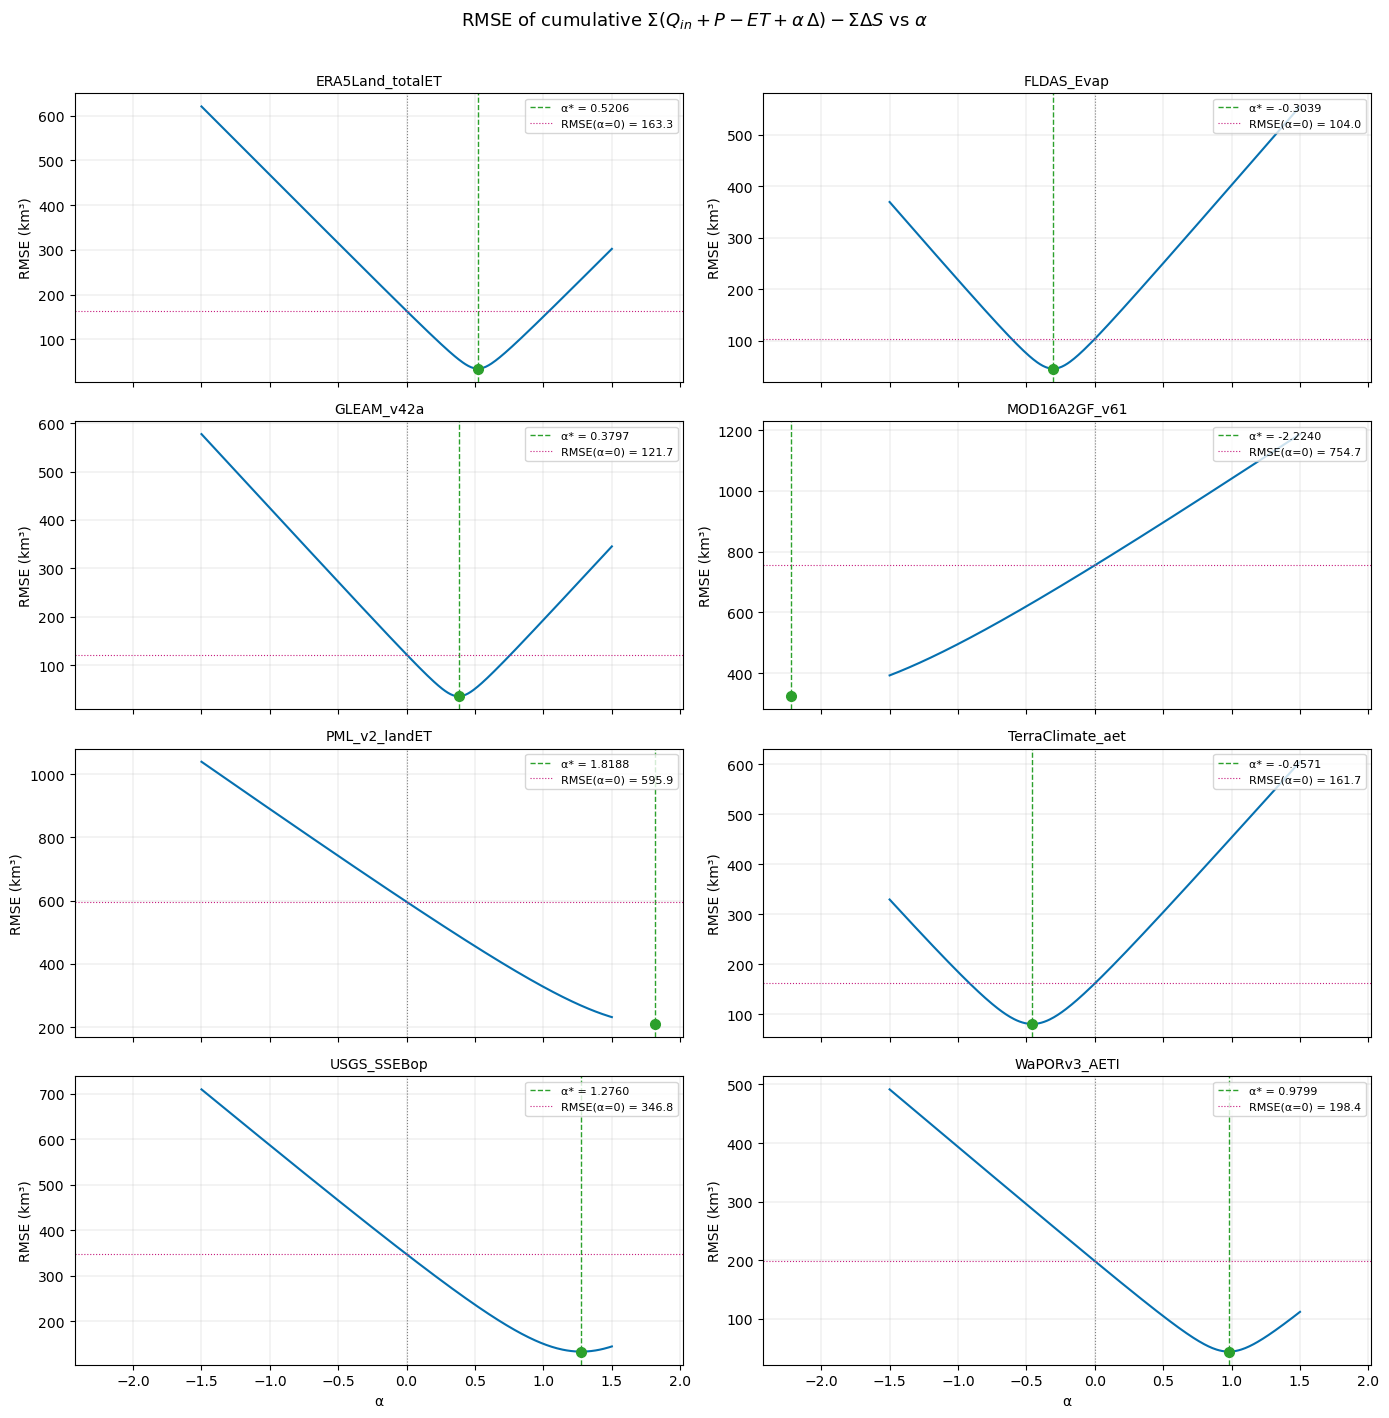

In [22]:
# ── RMSE vs α sensitivity curves (per ET model) ──
alpha_range = np.linspace(-1.5, 1.5, 301)

n_models_s = len(all_et)
ncols_s = 2
nrows_s = (n_models_s + ncols_s - 1) // ncols_s

fig, axes = plt.subplots(nrows_s, ncols_s, figsize=(14, 3.5 * nrows_s), sharex=True)
axes = axes.flatten()

for i, et_name in enumerate(all_et):
    ax = axes[i]
    dfc = dfc_tune.copy()
    dfc["ETkm3_model"] = et_tune[et_name]
    dfc = dfc[dfc["ETkm3_model"].notna()]
    if len(dfc) < 6:
        ax.set_visible(False)
        continue

    flux = dfc["Qin_km3"] + dfc["Pkm3"] - dfc["ETkm3_model"]
    ds_obs = dfc["dS_km3"]
    x = dfc["NW_NE_diff_cm"]

    cum_ds_v = ds_obs.cumsum().values
    cum_flux = flux.cumsum().values
    cum_x_v = x.cumsum().values

    # Compute RMSE for each α
    rmse_arr = np.array([
        np.sqrt(np.nanmean((cum_flux + a * cum_x_v - cum_ds_v) ** 2))
        for a in alpha_range
    ])

    # Optimal α from the results table
    row = df_results[df_results["ET_model"] == et_name].iloc[0]
    a_opt = row["alpha"]
    rmse_opt = row["RMSE_tuned_km3"]

    ax.plot(alpha_range, rmse_arr, lw=1.5, color="#0570b0")
    ax.axvline(a_opt, ls="--", lw=1, color="#2ca02c",
               label=f"α* = {a_opt:.4f}")
    ax.plot(a_opt, rmse_opt, "o", ms=7, color="#2ca02c", zorder=5)
    ax.axvline(0, ls=":", lw=0.8, color="0.5")
    ax.axhline(row["RMSE_base_km3"], ls=":", lw=0.8, color="#c51b7d",
               label=f"RMSE(α=0) = {row['RMSE_base_km3']:.1f}")

    ax.set_title(et_name, fontsize=10)
    ax.set_ylabel("RMSE (km³)")
    ax.legend(fontsize=8, loc="upper right")
    ax.grid(True, lw=0.2)

for j in range(n_models_s, len(axes)):
    axes[j].set_visible(False)

axes[-2].set_xlabel("α")
axes[-1].set_xlabel("α") if n_models_s % 2 == 0 else None
fig.suptitle(r"RMSE of cumulative $\Sigma(Q_{in}+P-ET+\alpha\,\Delta) - \Sigma\Delta S$ vs $\alpha$",
             fontsize=13, y=1.01)
plt.tight_layout()
fig.savefig(FIG_DIR / "rmse_vs_alpha.png", dpi=180, bbox_inches="tight")
plt.show()

## 10c — Two-parameter lateral-flux: α × (NW − NE) + β × (SW − NW)

Adds a second tunable flux proxy driven by the **SW → NW** head gradient,
capturing diffuse inflow into the domain when the SW block has higher storage.

$$Q_{in} + P - ET + \alpha\,(S_{NW} - S_{NE}) + \beta\,(S_{SW} - S_{NW}) \approx \Delta S$$

Both $\alpha$ and $\beta$ are optimised jointly via ordinary least squares on the
cumulative residual.  Positive $\beta$ means higher SW head aids closure.

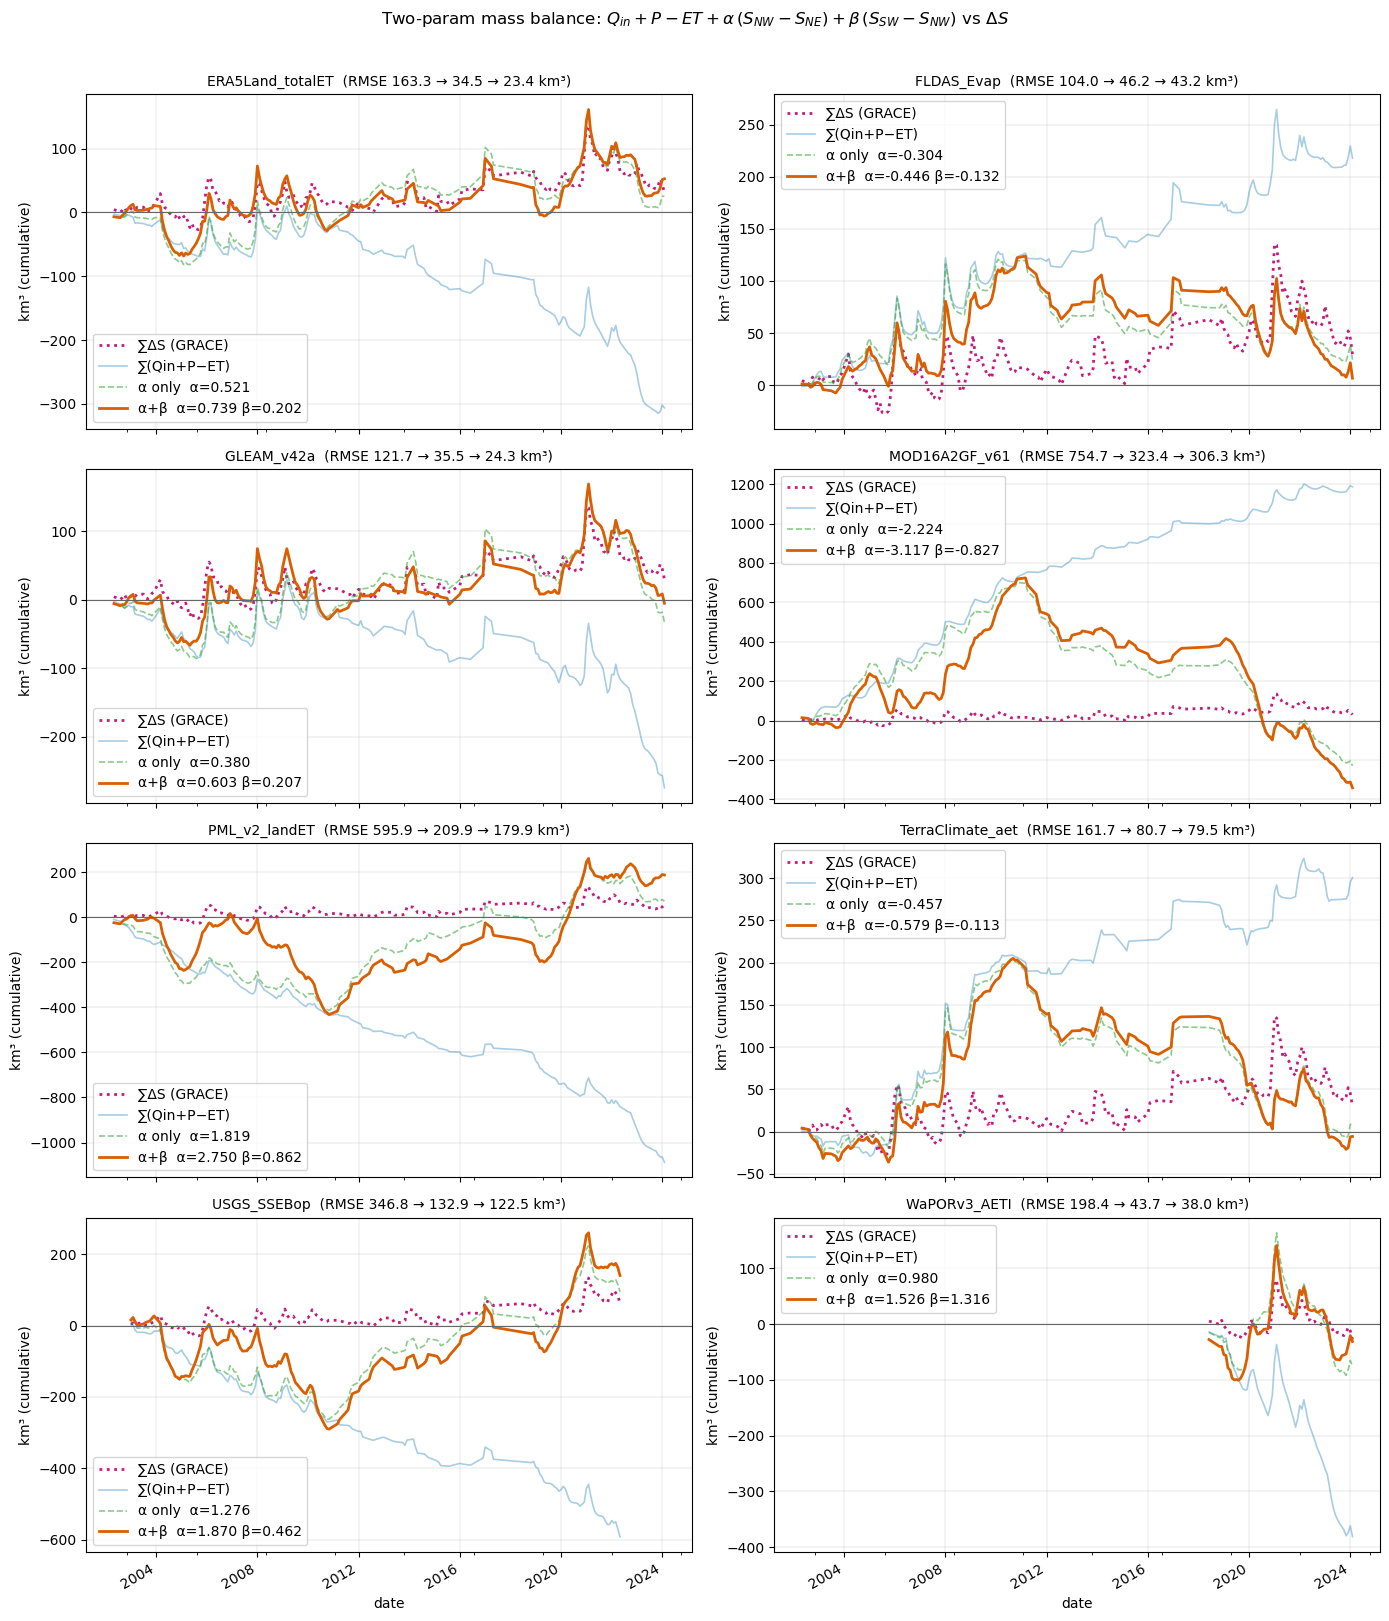


── Optimal (α, β) per ET model ──
        ET_model   alpha    beta  alpha_indep  RMSE_base_km3  RMSE_1param_km3  RMSE_2param_km3  improv_1p_pct  improv_2p_pct
ERA5Land_totalET  0.7389  0.2021       0.5206       163.3262          34.4864          23.3767        78.8849        85.6871
    WaPORv3_AETI  1.5264  1.3160       0.9799       198.3631          43.7287          37.9524        77.9552        80.8672
      GLEAM_v42a  0.6030  0.2067       0.3797       121.7171          35.5174          24.2621        70.8197        80.0668
   PML_v2_landET  2.7500  0.8623       1.8188       595.8920         209.9279         179.9083        64.7708        69.8086
     USGS_SSEBop  1.8697  0.4622       1.2760       346.8493         132.8748         122.4846        61.6909        64.6865
   MOD16A2GF_v61 -3.1169 -0.8267      -2.2240       754.7361         323.3631         306.2792        57.1555        59.4190
      FLDAS_Evap -0.4464 -0.1319      -0.3039       104.0336          46.2481          43.

In [23]:
# ── Two-parameter lateral-flux: α × (NW−NE) + β × (SW−NW) ──
# Joint OLS on cumulative residual:  min_{α,β} ||R + α·X1 + β·X2||²
# where R = cum(flux - ΔS), X1 = cum(NW-NE), X2 = cum(SW-NW)

base_mask_2p = df_balance[["Qin_km3", "Pkm3", "dS_km3",
                            "NW_NE_diff_cm", "SW_NW_diff_cm"]].notna().all(axis=1)
dfc_tune_2p = df_balance.loc[base_mask_2p].copy()
et_tune_2p = et_km3_wide.reindex(dfc_tune_2p.index)

# ── Pass 1: compute optimal (α, β) per ET model ──
results_2p = []
plot_data_2p = {}
for et_name in sorted(et_tune_2p.columns):
    dfc = dfc_tune_2p.copy()
    dfc["ETkm3_model"] = et_tune_2p[et_name]
    dfc = dfc[dfc["ETkm3_model"].notna()]
    if len(dfc) < 6:
        continue

    flux = dfc["Qin_km3"] + dfc["Pkm3"] - dfc["ETkm3_model"]
    ds_obs = dfc["dS_km3"]
    x1 = dfc["NW_NE_diff_cm"]
    x2 = dfc["SW_NW_diff_cm"]

    cum_resid = (flux - ds_obs).cumsum().values
    cum_x1 = x1.cumsum().values
    cum_x2 = x2.cumsum().values

    A = np.column_stack([cum_x1, cum_x2])
    params, _, _, _ = np.linalg.lstsq(A, -cum_resid, rcond=None)
    a_opt, b_opt = params

    row_1p = df_results[df_results["ET_model"] == et_name]
    a_indep = row_1p.iloc[0]["alpha"] if len(row_1p) else 0.0

    cum_ds = ds_obs.cumsum()
    cum_base = flux.cumsum()
    cum_1p = (flux + a_indep * x1).cumsum()
    cum_2p = (flux + a_opt * x1 + b_opt * x2).cumsum()

    rmse_base = np.sqrt(np.nanmean((cum_base.values - cum_ds.values) ** 2))
    rmse_1p   = np.sqrt(np.nanmean((cum_1p.values - cum_ds.values) ** 2))
    rmse_2p   = np.sqrt(np.nanmean((cum_2p.values - cum_ds.values) ** 2))
    improv_1p = (1 - rmse_1p / rmse_base) * 100 if rmse_base > 0 else 0
    improv_2p = (1 - rmse_2p / rmse_base) * 100 if rmse_base > 0 else 0

    results_2p.append({
        "ET_model": et_name,
        "alpha": a_opt, "beta": b_opt,
        "alpha_indep": a_indep,
        "RMSE_base_km3": rmse_base,
        "RMSE_1param_km3": rmse_1p,
        "RMSE_2param_km3": rmse_2p,
        "improv_1p_pct": improv_1p,
        "improv_2p_pct": improv_2p,
    })
    plot_data_2p[et_name] = dict(
        cum_ds=cum_ds, cum_base=cum_base, cum_1p=cum_1p, cum_2p=cum_2p,
        a_opt=a_opt, b_opt=b_opt, a_indep=a_indep,
        rmse_base=rmse_base, rmse_1p=rmse_1p, rmse_2p=rmse_2p)

df_results_2p = pd.DataFrame(results_2p).sort_values("improv_2p_pct", ascending=False)
all_et_2p = df_results_2p["ET_model"].tolist()
n_models_2p = len(all_et_2p)
ncols_2p = 2
nrows_2p = (n_models_2p + ncols_2p - 1) // ncols_2p

# ── Pass 2: plot ranked best → worst ──
fig, axes = plt.subplots(nrows_2p, ncols_2p, figsize=(14, 4 * nrows_2p), sharex=True)
axes = axes.flatten()

for i, et_name in enumerate(all_et_2p):
    ax = axes[i]
    d = plot_data_2p[et_name]
    d["cum_ds"].plot(ax=ax, color="#c51b7d", ls=":", lw=2, label="∑ΔS (GRACE)")
    d["cum_base"].plot(ax=ax, color="#0570b0", ls="-", lw=1.2, alpha=0.35,
                       label="∑(Qin+P−ET)")
    d["cum_1p"].plot(ax=ax, color="#2ca02c", ls="--", lw=1.2, alpha=0.55,
                     label=f"α only  α={d['a_indep']:.3f}")
    d["cum_2p"].plot(ax=ax, color="#d95f02", ls="-", lw=2,
                     label=f"α+β  α={d['a_opt']:.3f} β={d['b_opt']:.3f}")
    ax.axhline(0, lw=0.8, c="0.4")
    ax.set_title(f"{et_name}  (RMSE {d['rmse_base']:.1f} → {d['rmse_1p']:.1f} → {d['rmse_2p']:.1f} km³)",
                 fontsize=10)
    ax.set_ylabel("km³ (cumulative)")
    ax.grid(True, lw=0.2)
    ax.legend(fontsize=10, loc="best")

for j in range(n_models_2p, len(axes)):
    axes[j].set_visible(False)

fig.suptitle(
    r"Two-param mass balance: $Q_{in}+P-ET+"
    r"\alpha\,(S_{NW}-S_{NE})+\beta\,(S_{SW}-S_{NW})$ vs $\Delta S$",
    fontsize=12, y=1.01)
plt.tight_layout()
fig.savefig(FIG_DIR / "tuned_alpha_beta_cumulative.png", dpi=180, bbox_inches="tight")
plt.show()

# Summary table
print("\n── Optimal (α, β) per ET model (ranked by improvement) ──")
print(df_results_2p.to_string(index=False, float_format="%.4f"))

In [ ]:
# ── 2D RMSE heatmap: α vs β sensitivity (per ET model) ──
alpha_grid = np.linspace(-1.5, 2.0, 71)
beta_grid  = np.linspace(-1.5, 2.0, 71)

n_models_h = len(all_et_2p)
ncols_h = 2
nrows_h = (n_models_h + ncols_h - 1) // ncols_h

fig, axes = plt.subplots(nrows_h, ncols_h, figsize=(14, 5 * nrows_h))
axes = axes.flatten()

for i, et_name in enumerate(all_et_2p):
    ax = axes[i]
    dfc = dfc_tune_2p.copy()
    dfc["ETkm3_model"] = et_tune_2p[et_name]
    dfc = dfc[dfc["ETkm3_model"].notna()]
    if len(dfc) < 6:
        ax.set_visible(False)
        continue

    flux = dfc["Qin_km3"] + dfc["Pkm3"] - dfc["ETkm3_model"]
    ds_obs = dfc["dS_km3"]
    cum_ds_v = ds_obs.cumsum().values
    cum_flux = flux.cumsum().values
    cum_x1 = dfc["NW_NE_diff_cm"].cumsum().values
    cum_x2 = dfc["SW_NW_diff_cm"].cumsum().values

    rmse_grid = np.empty((len(beta_grid), len(alpha_grid)))
    for bi, bv in enumerate(beta_grid):
        for ai, av in enumerate(alpha_grid):
            rmse_grid[bi, ai] = np.sqrt(
                np.nanmean((cum_flux + av * cum_x1 + bv * cum_x2 - cum_ds_v) ** 2))

    # Optimal from table
    row = df_results_2p[df_results_2p["ET_model"] == et_name].iloc[0]
    a_opt, b_opt = row["alpha"], row["beta"]

    im = ax.pcolormesh(alpha_grid, beta_grid, rmse_grid,
                        shading="auto", cmap="viridis_r")
    ax.plot(a_opt, b_opt, "r*", ms=14, zorder=5, label=f"α*={a_opt:.3f}, β*={b_opt:.3f}")
    ax.plot(0, 0, "wx", ms=10, mew=2, zorder=5, label="no lateral flux")
    ax.set_xlabel("α  (NW→NE)")
    ax.set_ylabel("β  (SW→NW)")
    ax.set_title(f"{et_name}  (RMSE* = {row['RMSE_2param_km3']:.1f} km³)", fontsize=10)
    ax.legend(fontsize=8, loc="upper right")
    plt.colorbar(im, ax=ax, label="RMSE (km³)", shrink=0.85)

for j in range(n_models_h, len(axes)):
    axes[j].set_visible(False)

fig.suptitle(r"RMSE surface: $\alpha$ (NW$\to$NE) vs $\beta$ (SW$\to$NW)",
             fontsize=13, y=1.01)
plt.tight_layout()
fig.savefig(FIG_DIR / "rmse_alpha_beta_heatmap.png", dpi=180, bbox_inches="tight")
plt.show()

## 11 — Save outputs

In [ ]:
df_et_all.to_csv(FIG_DIR / "et_monthly.csv", index=False)
df_chirps.to_csv(FIG_DIR / "chirps_monthly.csv", index=False)
df_grace.to_csv(FIG_DIR / "grace_monthly.csv", index=False)
q_mohembo.to_csv(FIG_DIR / "mohembo_monthly.csv", index=False)

bal_out = (df_balance.reset_index().rename(columns={"index": "date"})
           if "date" not in df_balance.columns else df_balance)
bal_out.to_csv(FIG_DIR / "mass_balance.csv", index=False)

with open(FIG_DIR / "geometry_info.txt", "w") as fh:
    fh.write(f"GEOM = {GEOM_TAG}\n")
    fh.write(f"block_area_km2 = {block_area_m2 / 1e6:.1f}\n")
    fh.write(f"n_blocks = {len(USE_BLOCKS)}\n")
    for b in USE_BLOCKS:
        fh.write(f"  {b['block_id']} ({b['quadrant']}): "
                 f"lon {b['lon0']:.2f}–{b['lon1']:.2f}, "
                 f"lat {b['lat0']:.2f}–{b['lat1']:.2f}\n")

print(f"All outputs saved to {FIG_DIR.resolve()}")